# 01 - Exploratory Data Analysis

## ES | Objetivo

El objetivo de este notebook es explorar los datasets disponibles para comprender qué factores pueden estar relacionados con el burnout y la rotación laboral.

Durante este análisis se realizará:

- Carga de los datos.
- Inspección inicial del dataset.
- Verificación de la calidad de los datos.
- Análisis univariado.
- Análisis bivariado.
- Extracción de insights de negocio.

El conocimiento obtenido en esta fase servirá de base para el preprocesado de datos y el entrenamiento del modelo de Machine Learning.

---

## EN | Goal

The purpose of this notebook is to explore the available datasets to understand which factors may be related to employee burnout and attrition.

During this analysis we will:

- Load the datasets.
- Perform an initial data inspection.
- Verify data quality.
- Conduct univariate analysis.
- Conduct bivariate analysis.
- Extract business insights.

The knowledge obtained during this phase will be used as the foundation for data preprocessing and machine learning model development.

In [3]:
# ES: Librerías principales para análisis de datos.
# EN: Main libraries for data analysis.

import pandas as pd
import numpy as np

# ES: Librerías para visualización.
# EN: Libraries for visualization.

import matplotlib.pyplot as plt
import seaborn as sns

# ES: Se muestran todas las columnas para revisar mejor los datasets.
# EN: Show all columns to inspect the datasets more easily.

pd.set_option("display.max_columns", None)

# ES: Configuración básica de tamaño para los gráficos.
# EN: Basic figure size configuration for plots.

plt.rcParams["figure.figsize"] = (8, 5)

Matplotlib is building the font cache; this may take a moment.


## 1. Load Datasets

### ES

En esta sección cargamos los datasets originales en DataFrames de pandas.

Trabajar con DataFrames nos permitirá inspeccionar, limpiar y analizar la información de forma eficiente durante todo el proyecto.

---

### EN

In this section we load the raw datasets into pandas DataFrames.

Working with DataFrames allows us to inspect, clean and analyse the information efficiently throughout the project.

In [ ]:
# ES: Definir las rutas donde se encuentran los datasets.
# EN: Define the paths where the datasets are stored.

burnout_path = "../data/raw/wfh_burnout_dataset.csv"
attrition_path = "../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv"


In [ ]:
# ES: Cargar los datasets en DataFrames de pandas.
# EN: Load the datasets into pandas DataFrames.

burnout_df = pd.read_csv(burnout_path)
attrition_df = pd.read_csv(attrition_path)

In [ ]:
# ES: Mostrar las primeras filas del dataset de burnout.
# EN: Display the first rows of the burnout dataset.

display(burnout_df.head())

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score,burnout_risk
0,129,Weekday,7.74,5.99,3,7,0,50,7.50,74.80,4,3.51,17.23,Low
1,24,Weekday,8.48,7.23,3,5,0,63,7.31,86.36,4,5.15,24.01,Low
2,147,Weekend,8.39,7.14,1,5,0,27,6.73,89.23,8,7.85,51.46,Medium
3,42,Weekday,12.48,12.23,4,1,1,89,6.55,64.47,5,10.00,55.50,Medium
4,99,Weekend,8.85,7.35,4,6,0,40,8.03,98.62,3,3.45,11.95,Low


In [11]:
# ES: Mostrar las primeras filas del dataset de attrition.
# EN: Display the first rows of the attrition dataset.

display(attrition_df.head())

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


## 2. Burnout and Attrition Variables Overview

### ES

Antes de comenzar el análisis exploratorio es importante conocer qué variables contiene cada dataset y cuál es el tipo de dato asociado a cada una de ellas.

Esta revisión nos permitirá:

- Identificar las variables disponibles.
- Diferenciar variables numéricas y categóricas.
- Detectar posibles variables identificadoras.
- Comenzar a identificar la posible variable objetivo (*target*).

Conocer las variables es el primer paso para comprender la información disponible y planificar el preprocesado de los datos.

---

### EN

Before starting the exploratory analysis, it is important to understand which variables are available in each dataset and identify their corresponding data types.

This review allows us to:

- Identify the available features.
- Distinguish numerical and categorical variables.
- Detect potential identifier columns.
- Begin identifying the possible target variable.

Understanding the available variables is the first step towards planning the preprocessing stage and building the predictive models.

In [12]:
# ES: Crear un resumen de las columnas y sus tipos de datos.
# EN: Create a summary of the columns and their data types.

# Burnout dataset
burnout_summary = pd.DataFrame({
    "Column": burnout_df.columns,
    "Data Type": burnout_df.dtypes.values
})

print("Burnout Dataset Summary / Resumen del Dataset Burnout")
display(burnout_summary)

print("\n" + "=" * 70 + "\n")

# Attrition dataset
attrition_summary = pd.DataFrame({
    "Column": attrition_df.columns,
    "Data Type": attrition_df.dtypes.values
})

print("Attrition Dataset Summary / Resumen del Dataset Attrition")
display(attrition_summary)

Burnout Dataset Summary / Resumen del Dataset Burnout


,Column,Data Type
0,user_id,int64
1,day_type,str
2,work_hours,float64
3,screen_time_hours,float64
4,meetings_count,int64
5,breaks_taken,int64
6,after_hours_work,int64
7,app_switches,int64
8,sleep_hours,float64
9,task_completion,float64




Attrition Dataset Summary / Resumen del Dataset Attrition


,Column,Data Type
0,Age,int64
1,Attrition,str
2,BusinessTravel,str
3,DailyRate,int64
4,Department,str
5,DistanceFromHome,int64
6,Education,int64
7,EducationField,str
8,EmployeeCount,int64
9,EmployeeNumber,int64


### Interpretation

#### ES

La revisión de las variables muestra que ambos datasets tienen enfoques diferentes.

El dataset de **burnout** se centra en variables relacionadas con los hábitos de trabajo y el bienestar del empleado, mientras que el dataset de **attrition** incorpora información demográfica, organizativa y laboral.

Además, esta inspección permite distinguir entre variables numéricas y categóricas, información que será esencial durante la fase de preprocesado.

---

#### EN

The variable review shows that both datasets have different purposes.

The **burnout** dataset focuses on employee behaviour and wellbeing, whereas the **attrition** dataset contains demographic, organisational and job-related information.

This inspection also helps distinguish numerical and categorical variables, which will be essential during the preprocessing stage.

## 3. Burnout and Attrition Dataset Dimensions

### ES

En esta sección analizamos el tamaño de cada dataset para conocer el volumen de información disponible.

El número de observaciones y variables nos permitirá evaluar si los datos son adecuados para realizar un análisis exploratorio y entrenar modelos de Machine Learning.

---

### EN

In this section we analyse the size of each dataset to understand the amount of available information.

The number of observations and variables helps us evaluate whether the datasets are suitable for exploratory analysis and machine learning.

In [8]:
# ES: Mostrar el número de filas y columnas de cada dataset.
# EN: Display the number of rows and columns of each dataset.

print(f"Burnout dataset shape: {burnout_df.shape}")
print(f"Attrition dataset shape: {attrition_df.shape}")

Burnout dataset shape: (2000, 14)
Attrition dataset shape: (1470, 35)


### Interpretation

#### ES

El dataset de **burnout** contiene **2.000 registros y 14 variables**, mientras que el dataset de **attrition** dispone de **1.470 registros y 35 variables**.

Esto indica que ambos conjuntos de datos tienen un tamaño suficiente para realizar un análisis exploratorio y entrenar modelos de Machine Learning.

Además, se observa una diferencia importante en el número de variables. El dataset de burnout está más enfocado en el comportamiento diario del empleado (horas de trabajo, fatiga, aislamiento, etc.), mientras que el dataset de attrition ofrece una visión más amplia del contexto laboral, incluyendo variables demográficas, económicas y organizativas.

---

#### EN

The **burnout** dataset contains **2,000 records and 14 variables**, whereas the **attrition** dataset includes **1,470 records and 35 variables**.

Both datasets provide a sufficient number of observations for exploratory analysis and machine learning.

A key difference lies in the number of variables. The burnout dataset focuses on daily employee behaviour (working hours, fatigue, isolation, etc.), while the attrition dataset provides a broader HR perspective, including demographic, financial and organisational information.e robustness of predictive models, while the number of variables determines how detailed each employee profile or work situation can be described.

### Business Insight

#### ES

Aunque el dataset de burnout contiene menos variables que el de attrition, estas están directamente relacionadas con factores de riesgo asociados al agotamiento laboral.

Esto sugiere que el modelo predictivo podrá centrarse en variables de comportamiento con una relación más directa con el burnout, mientras que el dataset de attrition será especialmente útil para contextualizar los resultados desde una perspectiva de Recursos Humanos.

---

#### EN

Although the burnout dataset contains fewer variables than the attrition dataset, its features are directly related to employee wellbeing and burnout risk.

This suggests that the predictive model will rely mainly on behavioural variables, while the attrition dataset will provide valuable HR context for interpreting the results.

## 4. Burnout and Attrition Dataset Structure

### ES

En esta sección inspeccionamos la estructura interna de los datasets.

El objetivo es comprobar:

- El número de registros cargados.
- El número de valores no nulos por variable.
- El tipo de dato de cada columna.
- La consistencia general de los datasets.

Esta información nos permitirá detectar posibles problemas antes de comenzar el preprocesado.

---

### EN

In this section we inspect the internal structure of the datasets.

The objective is to verify:

- The number of loaded records.
- The number of non-null values for each feature.
- The data type of each column.
- The overall consistency of the datasets.

This information will help identify potential issues before the preprocessing stage.

In [13]:
# ES: Mostrar la estructura del dataset de burnout.
# EN: Display the structure of the burnout dataset.

print("Burnout Dataset Information")
burnout_df.info()

Burnout Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            2000 non-null   int64  
 1   day_type           2000 non-null   str    
 2   work_hours         2000 non-null   float64
 3   screen_time_hours  2000 non-null   float64
 4   meetings_count     2000 non-null   int64  
 5   breaks_taken       2000 non-null   int64  
 6   after_hours_work   2000 non-null   int64  
 7   app_switches       2000 non-null   int64  
 8   sleep_hours        2000 non-null   float64
 9   task_completion    2000 non-null   float64
 10  isolation_index    2000 non-null   int64  
 11  fatigue_score      2000 non-null   float64
 12  burnout_score      2000 non-null   float64
 13  burnout_risk       2000 non-null   str    
dtypes: float64(6), int64(6), str(2)
memory usage: 218.9 KB


In [14]:
# ES: Mostrar la estructura del dataset de attrition.
# EN: Display the structure of the attrition dataset.

print("Attrition Dataset Information")
attrition_df.info()

Attrition Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel             

### Interpretation

#### ES

La estructura de ambos datasets confirma que los datos se han cargado correctamente.

El dataset de **burnout** contiene 2.000 registros y 14 variables. Todas las columnas tienen 2.000 valores no nulos, por lo que inicialmente no se observan valores ausentes. Además, combina variables numéricas relacionadas con comportamiento laboral, descanso, fatiga y aislamiento, junto con variables categóricas como `day_type` y `burnout_risk`.

El dataset de **attrition** contiene 1.470 registros y 35 variables. Todas las columnas tienen 1.470 valores no nulos, por lo que tampoco se observan valores ausentes en esta primera revisión. La mayoría de variables son numéricas, aunque también incluye variables categóricas relevantes como `Attrition`, `Department`, `JobRole`, `OverTime` y `BusinessTravel`.

---

#### EN

The structure of both datasets confirms that the data has been loaded correctly.

The **burnout** dataset contains 2,000 records and 14 variables. All columns have 2,000 non-null values, so no missing values are observed at this stage. It combines numerical variables related to work behaviour, rest, fatigue and isolation, together with categorical variables such as `day_type` and `burnout_risk`.

The **attrition** dataset contains 1,470 records and 35 variables. All columns have 1,470 non-null values, so no missing values are observed in this initial review. Most variables are numerical, although it also includes relevant categorical variables such as `Attrition`, `Department`, `JobRole`, `OverTime` and `BusinessTravel`.

### Business Insight

#### ES

Ambos datasets parecen estar completos en cuanto a valores no nulos, lo que facilita el análisis inicial y reduce la necesidad de imputación de datos.

El dataset de burnout será el más adecuado para modelar el riesgo de burnout, ya que contiene variables directamente relacionadas con hábitos de trabajo y bienestar. El dataset de attrition puede aportar contexto adicional sobre factores de rotación laboral, como horas extra, satisfacción, rol, departamento y equilibrio vida-trabajo.

---

#### EN

Both datasets appear to be complete in terms of non-null values, which makes the initial analysis easier and reduces the need for data imputation.

The burnout dataset is the most suitable one for modelling burnout risk, as it contains variables directly related to work habits and wellbeing. The attrition dataset can provide additional context about employee turnover factors, such as overtime, satisfaction, job role, department and work-life balance.

## 5. Burnout and Attrition Data Quality

### ES

Antes de comenzar el análisis exploratorio es importante comprobar la calidad de los datos.

En esta sección revisaremos:

- Valores ausentes (*missing values*).
- Registros duplicados (*duplicated rows*).

Una buena calidad de los datos es esencial para garantizar que los análisis y modelos predictivos sean fiables.

---

### EN

Before starting the exploratory analysis, it is important to assess the quality of the datasets.

In this section we will review:

- Missing values.
- Duplicated rows.

Good data quality is essential to ensure reliable analyses and predictive models.

In [15]:
# ES: Contar los valores nulos de cada variable.
# EN: Count missing values for each variable.

burnout_missing = burnout_df.isnull().sum().to_frame(name="Missing Values")
attrition_missing = attrition_df.isnull().sum().to_frame(name="Missing Values")

print("Burnout Dataset - Missing Values")
display(burnout_missing)

print("\n" + "=" * 70 + "\n")

print("Attrition Dataset - Missing Values")
display(attrition_missing)

Burnout Dataset - Missing Values


,Missing Values
user_id,0
day_type,0
work_hours,0
screen_time_hours,0
meetings_count,0
breaks_taken,0
after_hours_work,0
app_switches,0
sleep_hours,0
task_completion,0




Attrition Dataset - Missing Values


,Missing Values
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


### Interpretation

#### ES

La revisión confirma que ninguno de los dos datasets presenta valores ausentes.

Todas las variables contienen el mismo número de registros que el total de observaciones, lo que indica que no será necesario aplicar técnicas de imputación durante el preprocesado.

---

#### EN

The review confirms that neither dataset contains missing values.

All variables have the same number of observations as the total number of records, meaning that no imputation techniques will be required during preprocessing.

### Business Insight

#### ES

Disponer de datasets completos simplifica considerablemente el proceso de preparación de los datos y reduce el riesgo de introducir sesgos derivados de la imputación de valores.

Esto permitirá centrar el esfuerzo en comprender el comportamiento de las variables y construir modelos predictivos más robustos.

---

#### EN

Having complete datasets significantly simplifies the data preparation process and reduces the risk of introducing bias through missing value imputation.

This allows the project to focus on understanding employee behaviour and building more robust predictive models.

In [16]:
# ES: Comprobar si existen registros duplicados.
# EN: Check for duplicated records.

burnout_duplicates = burnout_df.duplicated().sum()
attrition_duplicates = attrition_df.duplicated().sum()

print(f"Burnout duplicated rows: {burnout_duplicates}")
print(f"Attrition duplicated rows: {attrition_duplicates}")

Burnout duplicated rows: 0
Attrition duplicated rows: 0


### Interpretation

#### ES

La revisión muestra que ninguno de los dos datasets contiene registros duplicados.

Esto confirma que cada fila representa una observación única y que no será necesario eliminar duplicados antes de continuar con el análisis exploratorio.

---

#### EN

The review shows that neither dataset contains duplicated records.

This confirms that each row represents a unique observation and that no duplicated rows need to be removed before continuing with the exploratory analysis.

### Business Insight

#### ES

La ausencia de duplicados mejora la fiabilidad del análisis, ya que evita que determinados empleados o situaciones laborales tengan más peso del que deberían.

Esto permite analizar los patrones de burnout y attrition sin distorsiones provocadas por registros repetidos.

---

#### EN

The absence of duplicated records improves the reliability of the analysis, as it prevents specific employees or work situations from having more weight than they should.

This allows burnout and attrition patterns to be analysed without distortions caused by repeated records.

## 6. Burnout Dataset - Univariate Analysis

### ES

En esta sección analizamos cada variable de forma individual.

El objetivo es entender cómo se distribuyen las variables clave antes de estudiar relaciones entre ellas.

Nos centraremos en variables relevantes para burnout y attrition, como horas de trabajo, sueño, fatiga, satisfacción laboral, años en la empresa y rotación.

---

### EN

In this section we analyse each variable individually.

The goal is to understand how key variables are distributed before studying relationships between them.

We will focus on relevant variables for burnout and attrition, such as working hours, sleep, fatigue, job satisfaction, years at company and attrition.

## 6.1 Burnout Dataset - Numerical Variables

### ES

Primero analizamos las variables numéricas del dataset de burnout.

Estas variables describen hábitos de trabajo, descanso, productividad, aislamiento y fatiga.

---

### EN

First, we analyse the numerical variables from the burnout dataset.

These variables describe work habits, rest, productivity, isolation and fatigue.

In [18]:
# ES: Seleccionar variables numéricas clave del dataset de burnout.
# EN: Select key numerical variables from the burnout dataset.

burnout_numeric_columns = [
    "work_hours",
    "screen_time_hours",
    "meetings_count",
    "breaks_taken",
    "after_hours_work",
    "app_switches",
    "sleep_hours",
    "task_completion",
    "isolation_index",
    "fatigue_score",
    "burnout_score"
]

# ES: Mostrar estadísticas descriptivas de las variables seleccionadas.
# EN: Display descriptive statistics for the selected variables.

display(burnout_df[burnout_numeric_columns].describe())

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.955995,7.689495,3.728500,5.066000,0.15650,56.025500,6.894900,80.090670,4.875500,6.560825,35.656590
std,1.724214,1.983181,2.874877,1.762441,0.36342,23.702463,0.983893,12.708583,1.656011,2.218042,17.315039
min,4.730000,2.910000,0.000000,0.000000,0.00000,5.000000,3.580000,40.000000,3.000000,1.450000,6.060000
25%,7.750000,6.280000,2.000000,4.000000,0.00000,39.000000,6.320000,71.672500,3.000000,4.740000,21.005000
50%,8.535000,7.290000,3.000000,5.000000,0.00000,52.000000,7.080000,80.900000,5.000000,6.295000,32.330000
75%,9.980000,8.882500,5.000000,6.000000,0.00000,71.000000,7.570000,89.650000,6.000000,8.480000,47.475000
max,14.230000,13.980000,17.000000,11.000000,1.00000,152.000000,9.220000,100.000000,9.000000,10.000000,82.220000


### Interpretation

#### ES

Las variables numéricas del dataset de burnout muestran patrones relevantes para el análisis.

La jornada media es de aproximadamente **9 horas**, con casos que alcanzan más de **14 horas**, lo que indica posibles situaciones de sobrecarga laboral. El tiempo medio frente a pantalla es de unas **7,7 horas**, también elevado para un entorno de trabajo remoto.

La puntuación media de fatiga es **6,56 sobre 10**, lo que sugiere un nivel de cansancio moderado-alto en el conjunto de empleados. Además, el `burnout_score` presenta una media de **35,66**, pero alcanza valores superiores a **82**, lo que indica la existencia de perfiles con riesgo más elevado.

---

#### EN

The numerical variables in the burnout dataset show relevant patterns for the analysis.

The average working time is approximately **9 hours**, with some cases exceeding **14 hours**, which may indicate potential work overload. The average screen time is around **7.7 hours**, also high for a remote work environment.

The average fatigue score is **6.56 out of 10**, suggesting a moderate-to-high fatigue level among employees. Additionally, the `burnout_score` has an average value of **35.66**, but reaches values above **82**, indicating the presence of higher-risk profiles.

### Business Insight

#### ES

El dataset contiene variables directamente relacionadas con factores de riesgo de burnout, como horas de trabajo, tiempo frente a pantalla, trabajo fuera de horario, aislamiento, sueño y fatiga.

Esto refuerza la idea de que el modelo puede orientarse a construir una herramienta preventiva que evalúe si un puesto o patrón de trabajo puede aumentar el riesgo de burnout.

---

#### EN

The dataset contains variables directly related to burnout risk factors, such as working hours, screen time, after-hours work, isolation, sleep and fatigue.

This supports the idea that the model can be used to build a preventive tool that evaluates whether a job profile or work pattern may increase burnout risk.

## 6.2 Burnout Dataset - Distributions

### ES

En esta sección visualizamos la distribución de las variables numéricas clave del dataset de burnout.

Los histogramas nos ayudan a identificar:

- Variables con distribución equilibrada.
- Posibles valores extremos.
- Variables concentradas en rangos concretos.
- Patrones iniciales relacionados con el riesgo de burnout.

---

### EN

In this section we visualize the distribution of the key numerical variables from the burnout dataset.

Histograms help us identify:

- Variables with balanced distributions.
- Potential outliers.
- Variables concentrated in specific ranges.
- Initial patterns related to burnout risk.

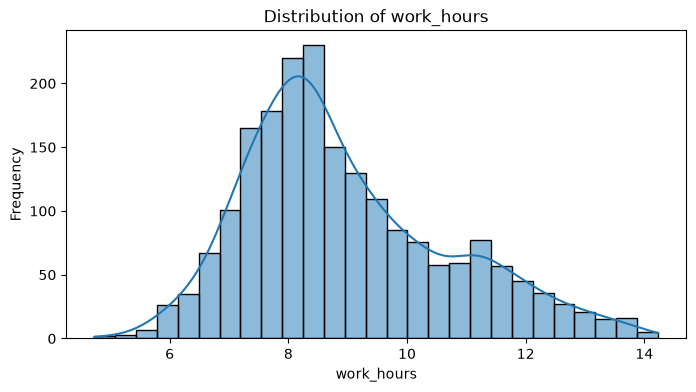

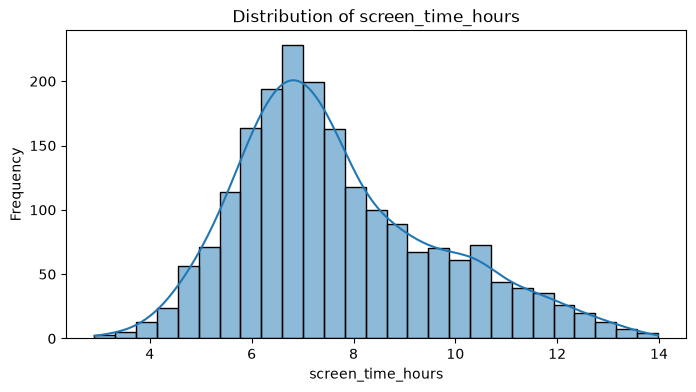

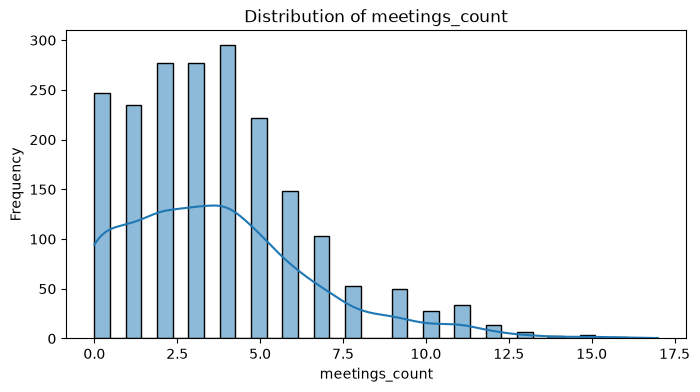

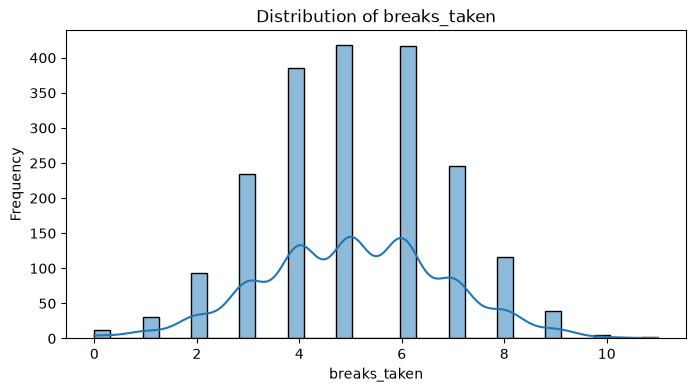

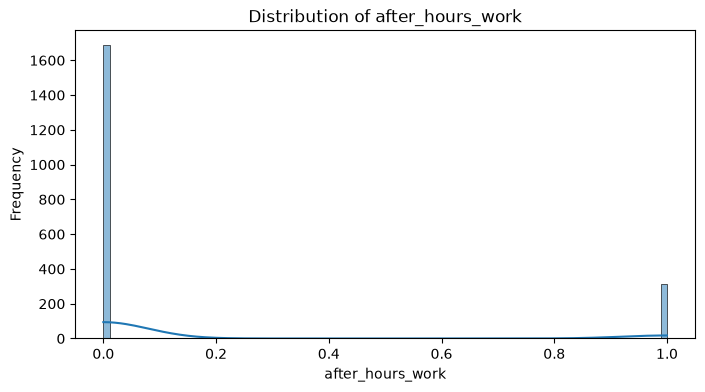

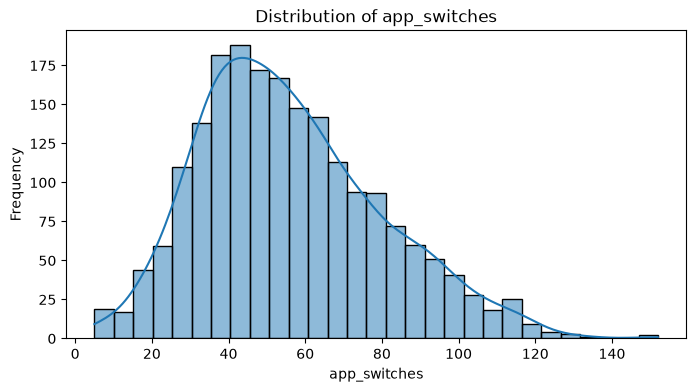

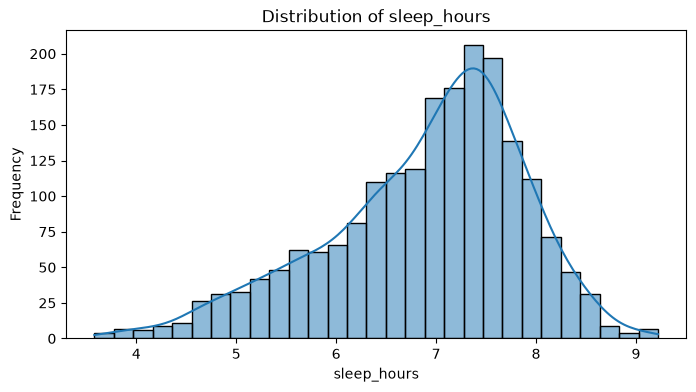

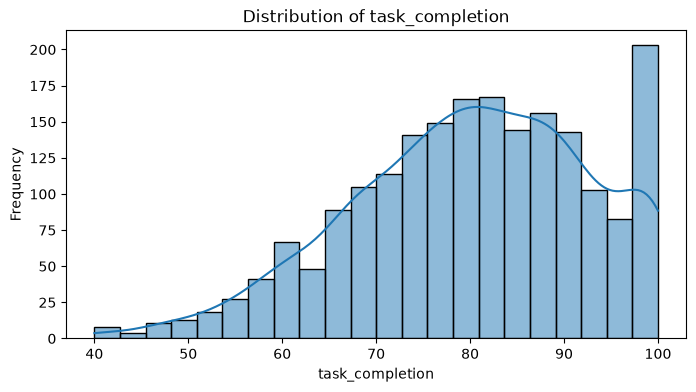

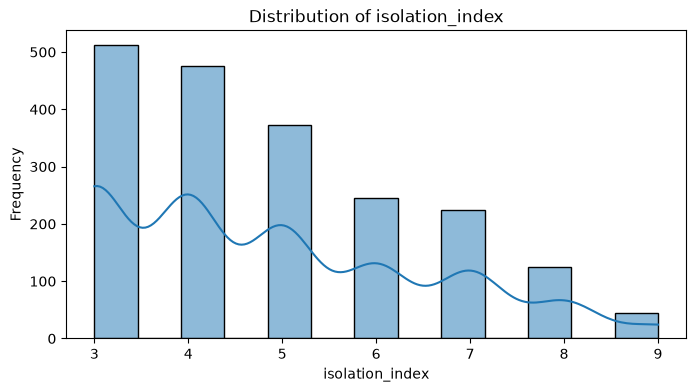

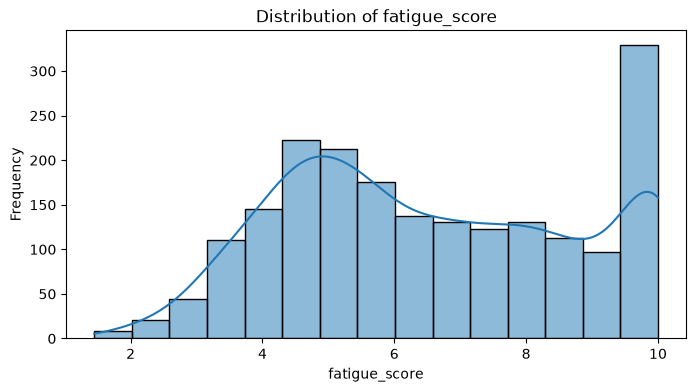

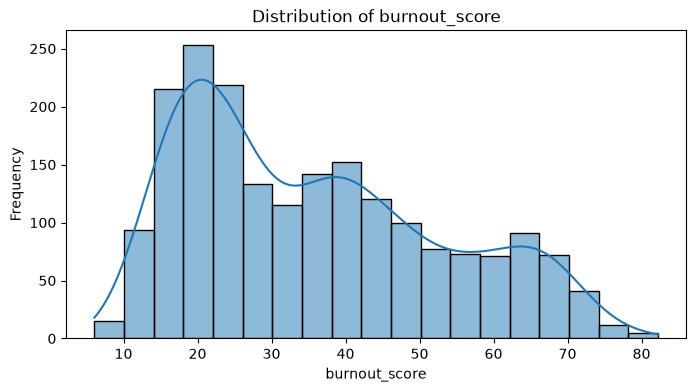

In [19]:
# ES: Crear histogramas para las variables numéricas clave del dataset de burnout.
# EN: Create histograms for the key numerical variables in the burnout dataset.

for column in burnout_numeric_columns:
    plt.figure(figsize=(8, 4))
    
    sns.histplot(
        data=burnout_df,
        x=column,
        kde=True
    )
    
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()

### Interpretation

#### ES

Las distribuciones muestran que la mayoría de variables presentan un comportamiento coherente con un entorno de trabajo remoto.

La jornada laboral (`work_hours`) se concentra alrededor de las **8-9 horas**, aunque existe un grupo de empleados que supera ampliamente las **10 horas diarias**, lo que podría representar situaciones de sobrecarga laboral.

El tiempo frente a pantalla (`screen_time_hours`) sigue una distribución muy similar a las horas trabajadas, indicando que gran parte de la jornada se desarrolla frente al ordenador.

Las variables `meetings_count` y `breaks_taken` presentan una distribución discreta, como era esperable, ya que representan recuentos de eventos diarios.

La variable `after_hours_work` muestra un claro desbalanceo, ya que la mayoría de empleados no trabaja fuera de su horario habitual, aunque existe un grupo minoritario que sí lo hace.

Las variables `sleep_hours`, `fatigue_score` y `burnout_score` muestran suficiente variabilidad entre empleados, lo que resulta especialmente interesante para el desarrollo del modelo predictivo.

---

#### EN

The distributions show that most variables behave consistently with a remote working environment.

Working hours (`work_hours`) are mainly concentrated around **8–9 hours**, although a group of employees works well above **10 hours per day**, which may indicate work overload.

`screen_time_hours` follows a distribution very similar to working hours, suggesting that most of the working day is spent in front of a computer.

Both `meetings_count` and `breaks_taken` display discrete distributions, which is expected since they represent daily event counts.

The `after_hours_work` variable is clearly imbalanced, as most employees do not work after regular hours, although a smaller group does.

Finally, `sleep_hours`, `fatigue_score` and `burnout_score` show considerable variability across employees, making them particularly interesting variables for predictive modelling.

### Business Insight

#### ES

Las distribuciones sugieren que el burnout no depende de un único factor, sino de la combinación de diferentes hábitos de trabajo.

Variables como las horas trabajadas, el tiempo frente a pantalla, el descanso, la fatiga y el trabajo fuera del horario laboral presentan suficiente variabilidad para ayudar al modelo a diferenciar distintos perfiles de riesgo.

Estos resultados apoyan el objetivo del proyecto: desarrollar una herramienta que permita identificar patrones de trabajo potencialmente asociados al burnout antes de que aparezcan consecuencias como una baja laboral o una disminución del bienestar.

---

#### EN

The distributions suggest that burnout is not driven by a single factor but rather by the combination of different work habits.

Variables such as working hours, screen time, sleep, fatigue and after-hours work show enough variability to help the model distinguish different risk profiles.

These findings support the main objective of the project: developing a tool capable of identifying work patterns associated with burnout before they result in sick leave or reduced employee wellbeing.

## 6.3 Burnout Target Analysis

### ES

En esta sección analizamos la variable objetivo principal del dataset de burnout.

La variable `burnout_risk` representa el nivel de riesgo de burnout y será una de las candidatas principales para construir el modelo predictivo.

Antes de entrenar cualquier modelo, es necesario comprobar cómo se distribuyen sus categorías.

---

### EN

In this section we analyse the main target variable from the burnout dataset.

The `burnout_risk` variable represents the burnout risk level and is one of the main candidates for building the predictive model.

Before training any model, it is necessary to check how its categories are distributed.

In [20]:
# ES: Mostrar la distribución absoluta y porcentual de la variable objetivo.
# EN: Display the absolute and percentage distribution of the target variable.

burnout_risk_distribution = burnout_df["burnout_risk"].value_counts().to_frame(name="Count")

burnout_risk_distribution["Percentage"] = (
    burnout_df["burnout_risk"].value_counts(normalize=True) * 100
).round(2)

display(burnout_risk_distribution)

,Count,Percentage
burnout_risk,,
Low,1019,50.95
Medium,843,42.15
High,138,6.90


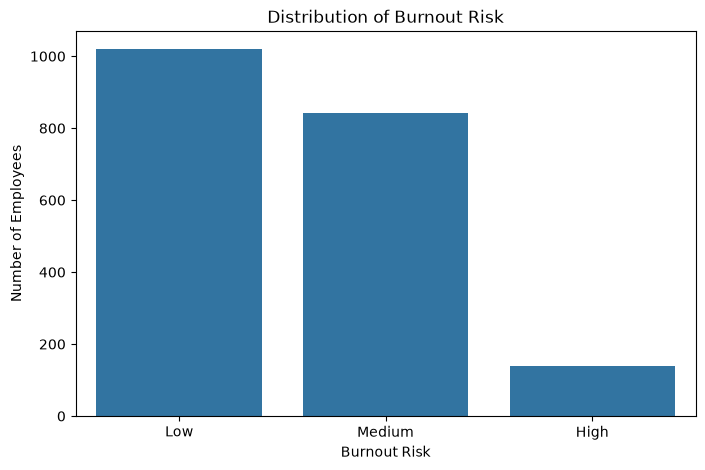

In [21]:
# ES: Visualizar la distribución de la variable objetivo.
# EN: Visualize the distribution of the target variable.

plt.figure(figsize=(8, 5))

sns.countplot(
    data=burnout_df,
    x="burnout_risk",
    order=burnout_df["burnout_risk"].value_counts().index
)

plt.title("Distribution of Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Number of Employees")
plt.show()

### Burnout Score and Burnout Risk Relationship

#### ES

Antes de utilizar `burnout_risk` como variable objetivo, comprobamos cómo se relaciona con `burnout_score`.

Esto es importante porque `burnout_risk` podría estar derivada directamente de `burnout_score`.

---

#### EN

Before using `burnout_risk` as the target variable, we check how it relates to `burnout_score`.

This is important because `burnout_risk` may be directly derived from `burnout_score`.

In [24]:
# ES: Analizar la relación entre burnout_score y burnout_risk.
# EN: Analyse the relationship between burnout_score and burnout_risk.

burnout_score_by_risk = (
    burnout_df
    .groupby("burnout_risk")["burnout_score"]
    .agg(["count", "min", "mean", "median", "max"])
    .loc[["Low", "Medium", "High"]]
    .round(2)
)

display(burnout_score_by_risk)

,count,min,mean,median,max
burnout_risk,,,,,
Low,1019,6.06,21.34,21.12,32.95
Medium,843,33.04,47.32,45.56,65.99
High,138,66.00,70.16,69.54,82.22


### Interpretation

#### ES

La variable objetivo `burnout_risk` presenta tres categorías: **Low**, **Medium** y **High**.

Aproximadamente el **51 %** de los empleados presentan un riesgo bajo de burnout, mientras que un **42 %** se sitúa en un riesgo medio. Únicamente un **6,9 %** de los registros corresponde a empleados con riesgo alto.

Además, la comparación entre `burnout_score` y `burnout_risk` muestra que ambas variables están estrechamente relacionadas.

Los valores de `burnout_score` se agrupan en intervalos claramente diferenciados:

- **Low:** valores inferiores a 33.
- **Medium:** valores entre 33 y 66.
- **High:** valores iguales o superiores a 66.

Esto sugiere que `burnout_risk` probablemente se ha construido a partir de `burnout_score`, aunque el dataset no documenta explícitamente la fórmula utilizada.

---

#### EN

The target variable `burnout_risk` contains three categories: **Low**, **Medium**, and **High**.

Approximately **51%** of employees present a low burnout risk, while **42%** belong to the medium-risk category. Only **6.9%** of the records correspond to employees with a high burnout risk.

In addition, the comparison between `burnout_score` and `burnout_risk` shows that both variables are closely related.

The `burnout_score` values are grouped into clearly separated ranges:

- **Low:** values below 33.
- **Medium:** values between 33 and 66.
- **High:** values equal to or above 66.

This suggests that `burnout_risk` was probably derived from `burnout_score`, although the dataset does not explicitly document the calculation method.

### Business Insight

#### ES

Desde el punto de vista del negocio, los empleados con **riesgo alto de burnout** representan el grupo de mayor interés, ya que son los candidatos con mayor probabilidad de sufrir una disminución del rendimiento, problemas de salud o incluso una baja laboral.

Sin embargo, esta categoría representa menos del **7 %** del dataset, lo que supone un **desbalanceo de clases**. Este aspecto deberá tenerse en cuenta durante el entrenamiento del modelo, ya que un algoritmo podría aprender únicamente las clases mayoritarias y obtener una alta precisión sin identificar correctamente los casos realmente críticos.

Además, dado que `burnout_risk` parece derivarse directamente de `burnout_score`, esta última variable no debería utilizarse como predictor del modelo. Incluirla podría provocar **data leakage**, es decir, que el modelo obtenga resultados artificialmente buenos al utilizar información que ya está contenida en la variable objetivo.

Por este motivo, el modelo predictivo debería construirse utilizando variables relacionadas con el comportamiento laboral, como las horas trabajadas, el descanso, el aislamiento, el tiempo frente a pantalla o la fatiga.

---

#### EN

From a business perspective, employees with **high burnout risk** are the most relevant group, as they are the most likely to experience reduced performance, health issues or even sick leave.

However, this category represents less than **7%** of the dataset, resulting in a **class imbalance**. This must be considered during model training, as an algorithm could learn only the majority classes and still achieve high accuracy while failing to identify the most critical cases.

In addition, since `burnout_risk` appears to be derived from `burnout_score`, the latter should not be used as a predictive feature. Including it could lead to **data leakage**, meaning that the model would produce artificially optimistic results by using information already contained in the target variable.

For this reason, the predictive model should be built using behavioural variables such as working hours, sleep, isolation, screen time and fatigue.

## 7. Burnout Dataset - Bivariate Analysis

### ES

En esta sección analizamos la relación entre diferentes variables y el riesgo de burnout.

El objetivo es identificar qué factores parecen estar más asociados con niveles altos de burnout.

Este análisis nos ayudará a seleccionar variables relevantes para el modelo predictivo y a construir una narrativa de negocio basada en los datos.

---

### EN

In this section we analyse the relationship between different variables and burnout risk.

The goal is to identify which factors appear to be more associated with high burnout levels.

This analysis will help us select relevant variables for the predictive model and build a data-driven business narrative.

## 7.1 Work Hours vs Burnout Risk

### ES

Primero analizamos si las horas trabajadas varían según el nivel de riesgo de burnout.

Esta relación es importante porque una mayor carga horaria puede ser una señal temprana de sobrecarga laboral.

---

### EN

First, we analyse whether working hours vary depending on the burnout risk level.

This relationship is important because longer working hours may be an early signal of work overload.

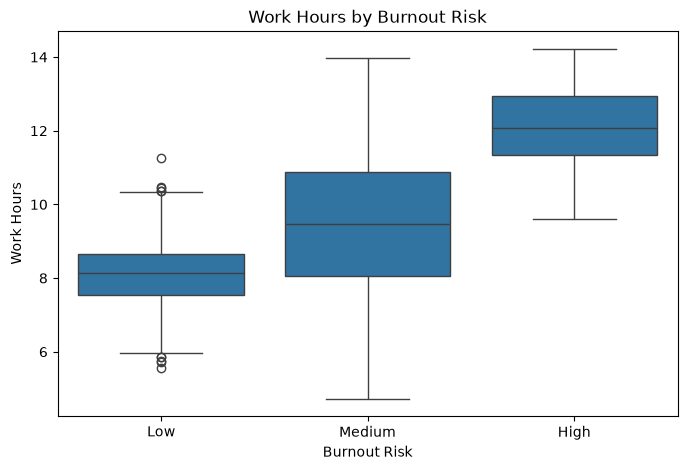

In [22]:
# ES: Comparar las horas trabajadas según el nivel de riesgo de burnout.
# EN: Compare working hours by burnout risk level.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=burnout_df,
    x="burnout_risk",
    y="work_hours",
    order=["Low", "Medium", "High"]
)

plt.title("Work Hours by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Work Hours")
plt.show()

In [23]:
# ES: Calcular estadísticas de horas trabajadas por nivel de burnout.
# EN: Calculate working hour statistics by burnout risk level.

work_hours_by_risk = (
    burnout_df
    .groupby("burnout_risk")["work_hours"]
    .agg(["count", "mean", "median", "min", "max"])
    .loc[["Low", "Medium", "High"]]
    .round(2)
)

display(work_hours_by_risk)

,count,mean,median,min,max
burnout_risk,,,,,
Low,1019,8.13,8.13,5.55,11.26
Medium,843,9.44,9.46,4.73,13.96
High,138,12.10,12.08,9.60,14.23


### Interpretation

#### ES

La comparación entre las horas trabajadas y el nivel de riesgo de burnout muestra una asociación clara.

Los empleados clasificados con riesgo **Low** trabajan una media de **8,13 horas** al día, mientras que los empleados con riesgo **Medium** alcanzan **9,44 horas** y los de riesgo **High** trabajan una media de **12,10 horas**.

Estos resultados indican que los perfiles con mayor riesgo de burnout presentan jornadas laborales considerablemente más largas. No obstante, este análisis únicamente identifica una asociación entre variables y no permite establecer una relación de causalidad.

---

#### EN

The comparison between working hours and burnout risk level shows a clear association.

Employees classified as **Low** risk work an average of **8.13 hours** per day, whereas **Medium** risk employees work **9.44 hours**, and **High** risk employees reach an average of **12.10 hours**.

These results indicate that higher burnout risk profiles tend to have considerably longer working days. However, this analysis only identifies an association between variables and does not establish a causal relationship.

### Business Insight

#### ES

Las horas trabajadas aparecen como uno de los factores más diferenciadores entre los distintos niveles de riesgo de burnout.

Desde una perspectiva preventiva, este resultado sugiere que la duración de la jornada laboral podría utilizarse como una de las variables de entrada de la aplicación para estimar el riesgo asociado a un determinado puesto de trabajo.

No obstante, el burnout es un fenómeno multifactorial. Por ello, las horas trabajadas deberán combinarse con otros factores como el descanso, la fatiga, el aislamiento o el trabajo fuera del horario habitual para obtener una estimación más fiable.

---

#### EN

Working hours emerge as one of the variables that best differentiates burnout risk levels.

From a preventive perspective, this suggests that working hours could be used as one of the application's input features to estimate the burnout risk associated with a specific job profile.

However, burnout is a multifactorial phenomenon. Therefore, working hours should be combined with other factors such as sleep, fatigue, isolation and after-hours work to provide a more reliable risk estimation.

## 7.2 Sleep Hours vs Burnout Risk

### ES

En esta sección analizamos si las horas de sueño varían según el nivel de riesgo de burnout.

El descanso es una variable relevante porque puede estar relacionado con fatiga, recuperación y bienestar general del empleado.

---

### EN

In this section we analyse whether sleep hours vary depending on the burnout risk level.

Rest is a relevant variable because it may be related to fatigue, recovery and overall employee wellbeing.

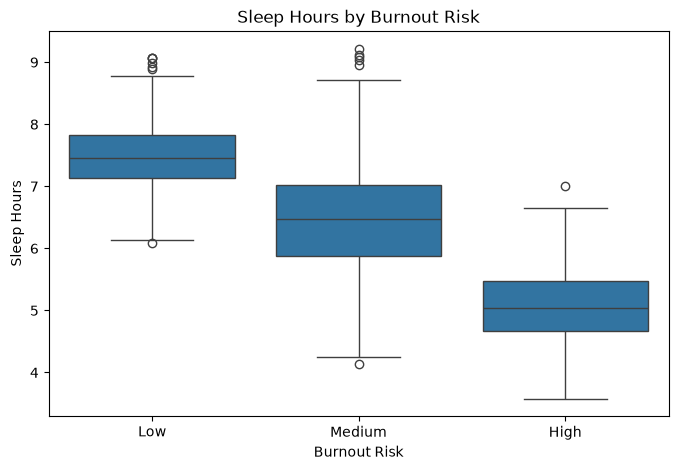

In [25]:
# ES: Comparar las horas de sueño según el nivel de riesgo de burnout.
# EN: Compare sleep hours by burnout risk level.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=burnout_df,
    x="burnout_risk",
    y="sleep_hours",
    order=["Low", "Medium", "High"]
)

plt.title("Sleep Hours by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Sleep Hours")
plt.show()

In [26]:
# ES: Calcular estadísticas de sueño por nivel de burnout.
# EN: Calculate sleep hour statistics by burnout risk level.

sleep_hours_by_risk = (
    burnout_df
    .groupby("burnout_risk")["sleep_hours"]
    .agg(["count", "mean", "median", "min", "max"])
    .loc[["Low", "Medium", "High"]]
    .round(2)
)

display(sleep_hours_by_risk)

,count,mean,median,min,max
burnout_risk,,,,,
Low,1019,7.49,7.46,6.08,9.07
Medium,843,6.47,6.47,4.13,9.22
High,138,5.07,5.04,3.58,7.01


### Interpretation

#### ES

La comparación entre las horas de sueño y el nivel de riesgo de burnout muestra una asociación clara.

Los empleados con riesgo **Low** duermen una media de **7,49 horas**, los empleados con riesgo **Medium** duermen **6,47 horas**, y los empleados con riesgo **High** duermen una media de **5,07 horas**.

Esto indica que los perfiles con mayor riesgo de burnout presentan menos horas de sueño. Al igual que en el análisis anterior, esta relación debe interpretarse como una asociación y no como una relación causal.

---

#### EN

The comparison between sleep hours and burnout risk level shows a clear association.

Employees classified as **Low** risk sleep an average of **7.49 hours**, **Medium** risk employees sleep **6.47 hours**, and **High** risk employees sleep an average of **5.07 hours**.

This indicates that higher burnout risk profiles tend to report fewer hours of sleep. As in the previous analysis, this relationship should be interpreted as an association rather than a causal relationship.

### Business Insight

#### ES

Las horas de sueño aparecen como un factor relevante para diferenciar niveles de riesgo de burnout.

Desde una perspectiva preventiva, la aplicación final podría utilizar el descanso como una variable clave para estimar el riesgo asociado a un determinado puesto o patrón de trabajo.

Este resultado también refuerza la idea de que el burnout debe analizarse como un fenómeno multifactorial, donde la carga laboral y la recuperación diaria interactúan entre sí.

---

#### EN

Sleep hours appear to be a relevant factor for distinguishing burnout risk levels.

From a preventive perspective, the final application could use rest as a key input variable to estimate the risk associated with a specific job profile or work pattern.

This result also reinforces the idea that burnout should be analysed as a multifactorial phenomenon, where workload and daily recovery interact with each other.

## 7.3 Fatigue Score vs Burnout Risk

### ES

En esta sección analizamos si la puntuación de fatiga varía según el nivel de riesgo de burnout.

La fatiga es una variable especialmente relevante porque puede reflejar el desgaste acumulado asociado a determinadas condiciones de trabajo.

---

### EN

In this section we analyse whether the fatigue score varies depending on the burnout risk level.

Fatigue is a particularly relevant variable because it may reflect accumulated strain associated with specific working conditions.

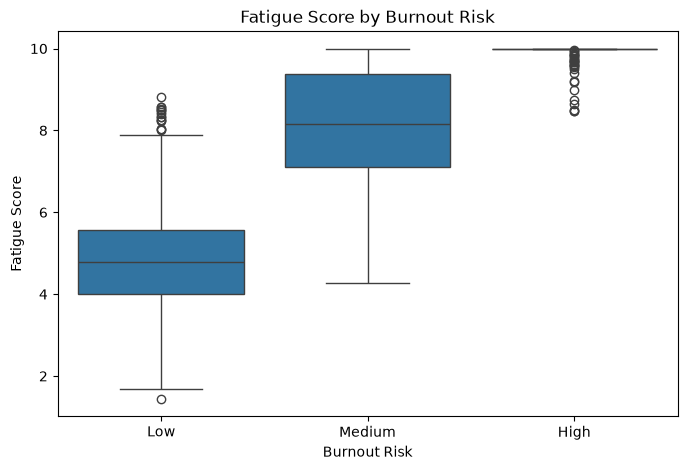

In [27]:
# ES: Comparar la puntuación de fatiga según el nivel de riesgo de burnout.
# EN: Compare fatigue score by burnout risk level.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=burnout_df,
    x="burnout_risk",
    y="fatigue_score",
    order=["Low", "Medium", "High"]
)

plt.title("Fatigue Score by Burnout Risk")
plt.xlabel("Burnout Risk")
plt.ylabel("Fatigue Score")
plt.show()

In [28]:
# ES: Calcular estadísticas de fatiga por nivel de burnout.
# EN: Calculate fatigue score statistics by burnout risk level.

fatigue_score_by_risk = (
    burnout_df
    .groupby("burnout_risk")["fatigue_score"]
    .agg(["count", "mean", "median", "min", "max"])
    .loc[["Low", "Medium", "High"]]
    .round(2)
)

display(fatigue_score_by_risk)

,count,mean,median,min,max
burnout_risk,,,,,
Low,1019,4.84,4.78,1.45,8.82
Medium,843,8.10,8.15,4.27,10.00
High,138,9.88,10.00,8.48,10.00


### Interpretation

#### ES

La puntuación de fatiga muestra una asociación muy marcada con el nivel de riesgo de burnout.

Los empleados clasificados con riesgo **Low** presentan una puntuación media de fatiga de **4,84**, mientras que los empleados con riesgo **Medium** alcanzan **8,10** y los empleados con riesgo **High** registran una media de **9,88**.

Esta diferencia es considerablemente superior a la observada en otras variables analizadas hasta el momento, lo que sugiere que la fatiga podría ser uno de los factores más estrechamente asociados al riesgo de burnout.

No obstante, este análisis identifica una asociación entre variables y no permite establecer una relación causal.

---

#### EN

Fatigue score shows a very strong association with burnout risk level.

Employees classified as **Low** risk have an average fatigue score of **4.84**, while **Medium** risk employees reach **8.10**, and **High** risk employees present an average score of **9.88**.

This difference is considerably larger than that observed for other variables analysed so far, suggesting that fatigue may be one of the factors most strongly associated with burnout risk.

However, this analysis identifies an association between variables and does not establish a causal relationship.

### Business Insight

#### ES

La fatiga se perfila como una de las variables más relevantes para estimar el riesgo de burnout.

Desde una perspectiva de negocio, este resultado refuerza la utilidad de incorporar indicadores relacionados con el bienestar del empleado en herramientas preventivas, ya que podrían ayudar a detectar situaciones de riesgo antes de que aparezcan consecuencias como una disminución del rendimiento o una baja laboral.

En la futura aplicación, la fatiga debería considerarse una de las variables principales para estimar el nivel de riesgo de un puesto de trabajo.

---

#### EN

Fatigue emerges as one of the most relevant variables for estimating burnout risk.

From a business perspective, this finding supports the inclusion of employee wellbeing indicators in preventive tools, as they may help detect risk situations before they result in reduced performance or sick leave.

In the final application, fatigue should be considered one of the main variables used to estimate the burnout risk associated with a specific job profile.

## 7.4 Correlation Analysis

### ES

En esta sección analizamos la correlación entre las variables numéricas del dataset de burnout.

El objetivo es identificar relaciones fuertes entre variables y detectar qué factores podrían estar más asociados con el `burnout_score`.

La correlación permite medir la fuerza y dirección de una relación lineal entre variables numéricas, aunque no implica causalidad.

---

### EN

In this section we analyse the correlation between the numerical variables in the burnout dataset.

The goal is to identify strong relationships between variables and detect which factors may be more associated with `burnout_score`.

Correlation measures the strength and direction of a linear relationship between numerical variables, although it does not imply causality.

In [29]:
# ES: Seleccionar variables numéricas para el análisis de correlación.
# EN: Select numerical variables for the correlation analysis.

burnout_correlation_columns = [
    "work_hours",
    "screen_time_hours",
    "meetings_count",
    "breaks_taken",
    "after_hours_work",
    "app_switches",
    "sleep_hours",
    "task_completion",
    "isolation_index",
    "fatigue_score",
    "burnout_score"
]

# ES: Calcular la matriz de correlación.
# EN: Calculate the correlation matrix.

burnout_correlation_matrix = burnout_df[burnout_correlation_columns].corr()

display(burnout_correlation_matrix.round(2))

,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,app_switches,sleep_hours,task_completion,isolation_index,fatigue_score,burnout_score
work_hours,1.00,0.98,0.47,-0.50,0.32,0.54,-0.52,-0.65,0.26,0.68,0.67
screen_time_hours,0.98,1.00,0.47,-0.66,0.31,0.54,-0.52,-0.65,0.26,0.66,0.66
meetings_count,0.47,0.47,1.00,-0.25,0.18,0.40,-0.36,-0.32,0.08,0.31,0.33
breaks_taken,-0.50,-0.66,-0.25,1.00,-0.14,-0.29,0.27,0.34,-0.15,-0.34,-0.35
after_hours_work,0.32,0.31,0.18,-0.14,1.00,0.20,-0.20,-0.23,0.14,0.25,0.30
app_switches,0.54,0.54,0.40,-0.29,0.20,1.00,-0.50,-0.36,0.21,0.58,0.54
sleep_hours,-0.52,-0.52,-0.36,0.27,-0.20,-0.50,1.00,0.33,-0.42,-0.69,-0.80
task_completion,-0.65,-0.65,-0.32,0.34,-0.23,-0.36,0.33,1.00,-0.21,-0.46,-0.46
isolation_index,0.26,0.26,0.08,-0.15,0.14,0.21,-0.42,-0.21,1.00,0.51,0.77
fatigue_score,0.68,0.66,0.31,-0.34,0.25,0.58,-0.69,-0.46,0.51,1.00,0.90


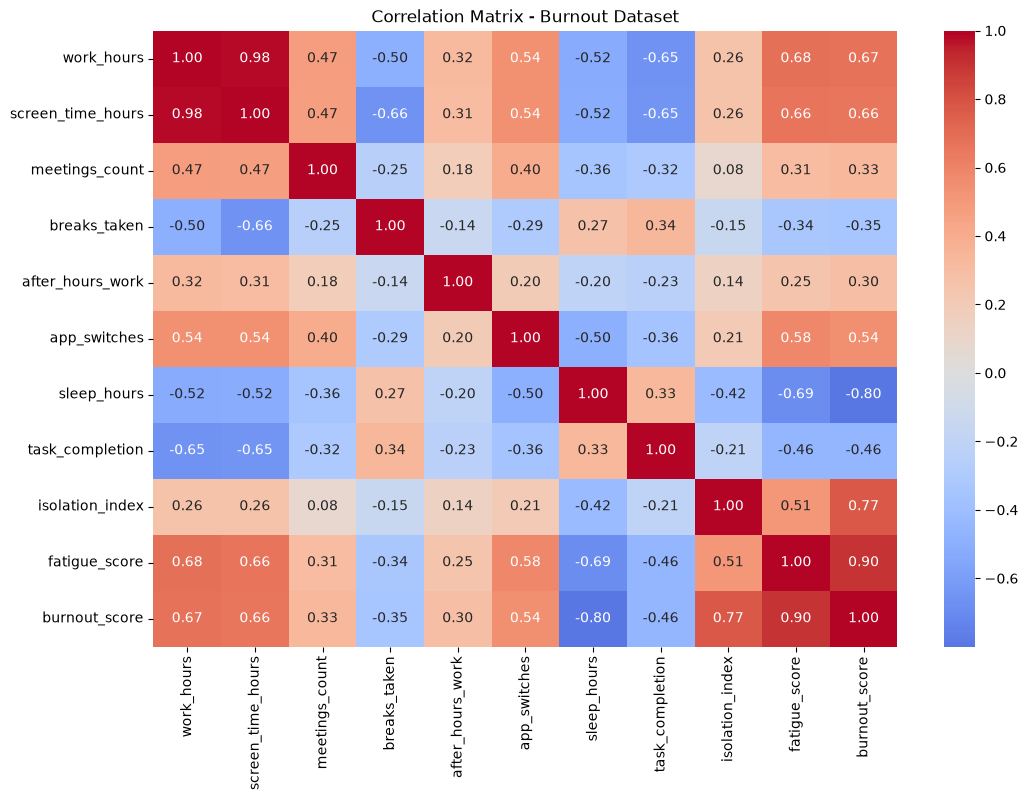

In [30]:
# ES: Visualizar la matriz de correlación con un heatmap.
# EN: Visualize the correlation matrix with a heatmap.

plt.figure(figsize=(12, 8))

sns.heatmap(
    burnout_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Burnout Dataset")
plt.show()

In [31]:
# ES: Ordenar las correlaciones con burnout_score.
# EN: Sort correlations with burnout_score.

burnout_score_correlations = (
    burnout_correlation_matrix["burnout_score"]
    .drop("burnout_score")
    .sort_values(ascending=False)
    .to_frame(name="Correlation with burnout_score")
    .round(2)
)

display(burnout_score_correlations)

,Correlation with burnout_score
fatigue_score,0.90
isolation_index,0.77
work_hours,0.67
screen_time_hours,0.66
app_switches,0.54
meetings_count,0.33
after_hours_work,0.30
breaks_taken,-0.35
task_completion,-0.46
sleep_hours,-0.80


### Interpretation

#### ES

El análisis de correlación permite identificar qué variables presentan una mayor asociación lineal con el `burnout_score`.

Las correlaciones positivas más elevadas corresponden a:

- `fatigue_score` (**0.90**)
- `isolation_index` (**0.77**)
- `work_hours` (**0.67**)
- `screen_time_hours` (**0.66**)

Por el contrario, las correlaciones negativas más fuertes son:

- `sleep_hours` (**-0.80**)
- `task_completion` (**-0.46**)
- `breaks_taken` (**-0.35**)

Estos resultados indican que mayores niveles de fatiga, aislamiento y carga de trabajo tienden a estar asociados con puntuaciones más altas de burnout, mientras que un mayor descanso, una mayor productividad y un mayor número de pausas aparecen asociados con menores niveles de burnout.

Como en los análisis anteriores, estas relaciones representan asociaciones estadísticas y no permiten establecer relaciones causales.

---

#### EN

The correlation analysis identifies which variables have the strongest linear association with `burnout_score`.

The strongest positive correlations are:

- `fatigue_score` (**0.90**)
- `isolation_index` (**0.77**)
- `work_hours` (**0.67**)
- `screen_time_hours` (**0.66**)

The strongest negative correlations are:

- `sleep_hours` (**-0.80**)
- `task_completion` (**-0.46**)
- `breaks_taken` (**-0.35**)

These results indicate that higher fatigue, isolation and workload tend to be associated with higher burnout scores, while more sleep, higher task completion and more breaks are associated with lower burnout levels.

As in the previous analyses, these relationships represent statistical associations and do not imply causality.

## Business Insight

#### ES

Los resultados obtenidos permiten identificar los factores que, dentro de este dataset, presentan una mayor asociación con el riesgo de burnout.

Este análisis proporciona una primera aproximación a las variables que podrían utilizarse para construir una herramienta preventiva capaz de estimar el riesgo de burnout a partir de las condiciones de trabajo de un puesto.

En particular, la fatiga, el aislamiento, las horas trabajadas y el tiempo frente a pantalla aparecen como los principales factores de riesgo, mientras que el descanso, las pausas durante la jornada y la capacidad para completar tareas parecen actuar como factores asociados a un menor riesgo.

Estos resultados servirán como base para la selección de variables durante la fase de entrenamiento del modelo.

---

#### EN

The results identify the factors that, within this dataset, show the strongest association with burnout risk.

This analysis provides an initial basis for selecting the variables that could be used to build a preventive tool capable of estimating burnout risk from working conditions.

In particular, fatigue, isolation, working hours and screen time emerge as the strongest risk-related factors, while sleep, regular breaks and task completion appear to be associated with lower burnout levels.

These findings will guide feature selection during the model training stage.

## 8. IBM HR Dataset - Variance and Correlation Analysis

### ES

En esta sección comenzamos el análisis del dataset de IBM HR.

El objetivo es estudiar la variabilidad de las variables numéricas y analizar las correlaciones entre ellas.

Este análisis nos ayudará a entender qué variables laborales, organizativas o personales pueden estar relacionadas con la rotación de empleados (*attrition*) y cuáles podrían aportar contexto útil al análisis de burnout.

---

### EN

In this section we start analysing the IBM HR dataset.

The goal is to study the variability of numerical variables and analyse correlations between them.

This analysis will help us understand which job-related, organisational or personal variables may be related to employee attrition and which ones could provide useful context for the burnout analysis.

## 8.1 IBM Numerical Variables

### ES

Primero seleccionamos las variables numéricas del dataset de IBM HR.

Este paso nos permitirá calcular estadísticas descriptivas, varianza y correlaciones entre variables.

---

### EN

First, we select the numerical variables from the IBM HR dataset.

This step allows us to calculate descriptive statistics, variance and correlations between variables.

In [32]:
# ES: Seleccionar las variables numéricas del dataset de IBM HR.
# EN: Select numerical variables from the IBM HR dataset.

attrition_numeric_columns = attrition_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("IBM HR numerical columns:")
print(attrition_numeric_columns)

IBM HR numerical columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [33]:
# ES: Mostrar estadísticas descriptivas de las variables numéricas.
# EN: Display descriptive statistics for numerical variables.

display(attrition_df[attrition_numeric_columns].describe().round(2))

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00
mean,36.92,802.49,9.19,2.91,1.0,1024.87,2.72,65.89,2.73,2.06,2.73,6502.93,14313.10,2.69,15.21,3.15,2.71,80.0,0.79,11.28,2.80,2.76,7.01,4.23,2.19,4.12
std,9.14,403.51,8.11,1.02,0.0,602.02,1.09,20.33,0.71,1.11,1.10,4707.96,7117.79,2.50,3.66,0.36,1.08,0.0,0.85,7.78,1.29,0.71,6.13,3.62,3.22,3.57
min,18.00,102.00,1.00,1.00,1.0,1.00,1.00,30.00,1.00,1.00,1.00,1009.00,2094.00,0.00,11.00,3.00,1.00,80.0,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,30.00,465.00,2.00,2.00,1.0,491.25,2.00,48.00,2.00,1.00,2.00,2911.00,8047.00,1.00,12.00,3.00,2.00,80.0,0.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00
50%,36.00,802.00,7.00,3.00,1.0,1020.50,3.00,66.00,3.00,2.00,3.00,4919.00,14235.50,2.00,14.00,3.00,3.00,80.0,1.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00
75%,43.00,1157.00,14.00,4.00,1.0,1555.75,4.00,83.75,3.00,3.00,4.00,8379.00,20461.50,4.00,18.00,3.00,4.00,80.0,1.00,15.00,3.00,3.00,9.00,7.00,3.00,7.00
max,60.00,1499.00,29.00,5.00,1.0,2068.00,4.00,100.00,4.00,5.00,4.00,19999.00,26999.00,9.00,25.00,4.00,4.00,80.0,3.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00


#### ES

El dataset de IBM HR contiene variables numéricas con distintos niveles de variabilidad.

Algunas variables parecen ser constantes o identificadores, como `EmployeeCount`, `StandardHours` y `EmployeeNumber`. Estas variables probablemente no aportarán valor analítico ni predictivo.

También observamos variables laborales relevantes como `Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `JobSatisfaction`, `WorkLifeBalance` y `EnvironmentSatisfaction`, que pueden ayudar a entender patrones de rotación laboral.

---

#### EN

The IBM HR dataset contains numerical variables with different levels of variability.

Some variables appear to be constant values or identifiers, such as `EmployeeCount`, `StandardHours`, and `EmployeeNumber`. These variables will probably not provide analytical or predictive value.

We also observe relevant job-related variables such as `Age`, `MonthlyIncome`, `TotalWorkingYears`, `YearsAtCompany`, `JobSatisfaction`, `WorkLifeBalance`, and `EnvironmentSatisfaction`, which may help explain employee attrition patterns.

### Business Insight

#### ES

Este primer análisis permite identificar variables que podrían ser útiles para explicar la rotación de empleados y variables que probablemente deberían excluirse en fases posteriores.

Desde una perspectiva de negocio, variables como satisfacción laboral, equilibrio vida-trabajo, antigüedad, ingresos y experiencia pueden aportar contexto sobre qué perfiles laborales podrían estar más expuestos a desgaste, desmotivación o abandono de la empresa.

---

#### EN

This initial analysis helps identify variables that may be useful for explaining employee attrition and variables that should probably be excluded in later stages.

From a business perspective, variables such as job satisfaction, work-life balance, tenure, income and experience can provide context about which employee profiles may be more exposed to strain, disengagement or leaving the company.

## 8.2 IBM Variance Analysis

### ES

En esta sección analizamos la varianza de las variables numéricas del dataset de IBM HR.

La varianza mide cuánto se dispersan los valores de una variable respecto a su media.

Este análisis nos ayuda a detectar:

- Variables constantes.
- Variables con muy poca variabilidad.
- Variables que podrían no aportar información útil al modelo.

---

### EN

In this section we analyse the variance of the numerical variables in the IBM HR dataset.

Variance measures how much the values of a variable are spread around their mean.

This analysis helps us detect:

- Constant variables.
- Variables with very low variability.
- Variables that may not provide useful information for the model.

In [34]:
# ES: Calcular la varianza de las variables numéricas del dataset IBM HR.
# EN: Calculate the variance of numerical variables in the IBM HR dataset.

attrition_variance = (
    attrition_df[attrition_numeric_columns]
    .var()
    .sort_values(ascending=False)
    .to_frame(name="Variance")
    .round(2)
)

display(attrition_variance)

,Variance
MonthlyRate,50662878.17
MonthlyIncome,22164857.07
EmployeeNumber,362433.30
DailyRate,162819.59
HourlyRate,413.29
Age,83.46
DistanceFromHome,65.72
TotalWorkingYears,60.54
YearsAtCompany,37.53
PercentSalaryHike,13.40


In [35]:
# ES: Identificar variables con varianza igual a cero.
# EN: Identify variables with zero variance.

zero_variance_columns = attrition_variance[attrition_variance["Variance"] == 0]

display(zero_variance_columns)

,Variance
EmployeeCount,0.0
StandardHours,0.0


### Interpretation

#### ES

El análisis de varianza muestra que la mayoría de las variables presentan suficiente variabilidad para ser consideradas durante el desarrollo del modelo.

Sin embargo, dos variables (`EmployeeCount` y `StandardHours`) presentan una varianza igual a cero, lo que significa que toman exactamente el mismo valor para todos los empleados.

Al no existir variabilidad, estas variables no contienen información útil para diferenciar perfiles y no aportarán capacidad predictiva al modelo.

Además, aunque `EmployeeNumber` presenta una elevada varianza, actúa como un identificador único de cada empleado y tampoco aporta información relevante para explicar la rotación laboral.

---

#### EN

The variance analysis shows that most variables have sufficient variability to be considered during model development.

However, two variables (`EmployeeCount` and `StandardHours`) have zero variance, meaning that they take exactly the same value for every employee.

Since there is no variability, these variables do not contain useful information for distinguishing employee profiles and will not contribute to the predictive model.

In addition, although `EmployeeNumber` has a high variance, it acts as a unique employee identifier and therefore does not provide useful information for explaining employee attrition.

### Business Insight

#### ES

Este análisis permite identificar variables que pueden eliminarse antes del entrenamiento del modelo sin perder información relevante.

Eliminar variables constantes o identificadores reduce el ruido del dataset, simplifica el proceso de modelado y mejora la interpretabilidad de los resultados.

Como consecuencia, `EmployeeCount`, `StandardHours` y `EmployeeNumber` se consideran candidatas para ser excluidas durante la fase de preprocesado.

---

#### EN

This analysis identifies variables that can be removed before model training without losing relevant information.

Removing constant variables and identifiers reduces dataset noise, simplifies the modelling process and improves the interpretability of the results.

As a consequence, `EmployeeCount`, `StandardHours` and `EmployeeNumber` are considered candidates for removal during the preprocessing stage.

## 8.3 Attrition Analysis

### ES

En esta sección analizamos la variable objetivo del dataset de IBM HR: `Attrition`.

Esta variable indica si un empleado continúa trabajando en la empresa o si la ha abandonado.

Comprender su distribución es fundamental antes de estudiar qué factores laborales pueden estar asociados con la rotación de empleados.

---

### EN

In this section we analyse the target variable of the IBM HR dataset: `Attrition`.

This variable indicates whether an employee remains in the company or has left it.

Understanding its distribution is essential before studying which work-related factors may be associated with employee turnover.

In [36]:
# ES: Mostrar la distribución absoluta y porcentual de Attrition.
# EN: Display the absolute and percentage distribution of Attrition.

attrition_distribution = (
    attrition_df["Attrition"]
    .value_counts()
    .to_frame(name="Count")
)

attrition_distribution["Percentage"] = (
    attrition_df["Attrition"]
    .value_counts(normalize=True) * 100
).round(2)

display(attrition_distribution)

,Count,Percentage
Attrition,,
No,1233,83.88
Yes,237,16.12


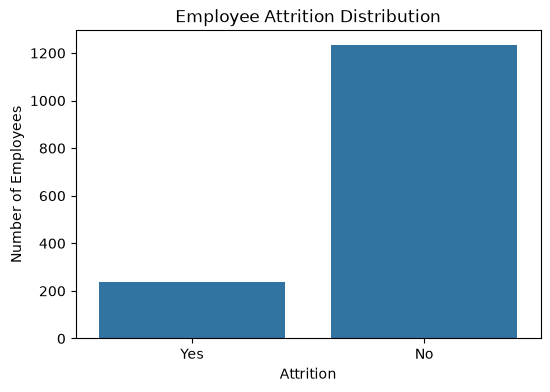

In [37]:
# ES: Visualizar la distribución de Attrition.
# EN: Visualize the Attrition distribution.

plt.figure(figsize=(6,4))

sns.countplot(
    data=attrition_df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")

plt.show()

## 8.4 OverTime vs Attrition

### ES

En esta sección analizamos la relación entre las horas extra (`OverTime`) y la rotación de empleados (`Attrition`).

`Attrition` indica si el empleado ha dejado la empresa, pero no diferencia entre salida voluntaria, despido u otros motivos.

Este análisis es relevante porque las horas extra pueden estar asociadas con sobrecarga laboral, desgaste y mayor probabilidad de abandono.

---

### EN

In this section we analyse the relationship between overtime (`OverTime`) and employee attrition (`Attrition`).

`Attrition` indicates whether an employee has left the company, but it does not distinguish between voluntary resignation, dismissal or other reasons.

This analysis is relevant because overtime may be associated with work overload, strain and a higher likelihood of employee turnover.

In [38]:
# ES: Calcular la tasa de attrition según horas extra.
# EN: Calculate attrition rate by overtime status.

overtime_attrition_rate = (
    attrition_df
    .groupby("OverTime")["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

overtime_attrition_rate["Percentage"] = (
    overtime_attrition_rate["Percentage"] * 100
).round(2)

display(overtime_attrition_rate)

,OverTime,Attrition,Percentage
0,No,No,89.56
1,No,Yes,10.44
2,Yes,No,69.47
3,Yes,Yes,30.53


In [39]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

overtime_attrition_yes = overtime_attrition_rate[
    overtime_attrition_rate["Attrition"] == "Yes"
]

display(overtime_attrition_yes)

,OverTime,Attrition,Percentage
1,No,Yes,10.44
3,Yes,Yes,30.53


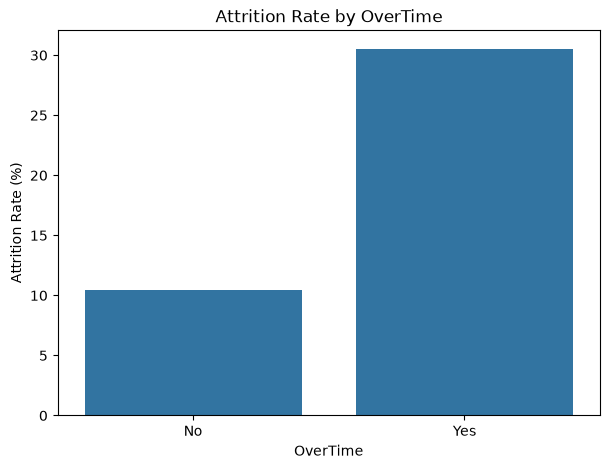

In [40]:
# ES: Visualizar la tasa de attrition según horas extra.
# EN: Visualize attrition rate by overtime status.

plt.figure(figsize=(7, 5))

sns.barplot(
    data=overtime_attrition_yes,
    x="OverTime",
    y="Percentage"
)

plt.title("Attrition Rate by OverTime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Interpretation

#### ES

La tasa de attrition es claramente superior entre los empleados que realizan horas extra.

Entre los empleados que **no** hacen horas extra, el porcentaje de attrition es del **10,44 %**. En cambio, entre los empleados que **sí** hacen horas extra, la tasa sube hasta el **30,53 %**.

Esto indica que los empleados con `OverTime = Yes` presentan una proporción de salida casi tres veces mayor que los empleados sin horas extra.

---

#### EN

The attrition rate is clearly higher among employees who work overtime.

Among employees who do **not** work overtime, the attrition rate is **10.44%**. In contrast, among employees who **do** work overtime, the rate increases to **30.53%**.

This indicates that employees with `OverTime = Yes` show an attrition proportion almost three times higher than employees without overtime.

### Business Insight

#### ES

Las horas extra aparecen como una variable muy relevante para explicar la rotación de empleados.

Desde una perspectiva de Recursos Humanos, este resultado sugiere que la sobrecarga laboral puede estar asociada con una mayor probabilidad de abandono de la empresa.

Para el proyecto, este hallazgo conecta con el análisis de burnout, donde las jornadas más largas también aparecían asociadas con mayor riesgo. Aunque los datasets son independientes, ambos apuntan a la importancia de controlar la carga laboral como factor preventivo.

---

#### EN

Overtime appears to be a highly relevant variable for explaining employee attrition.

From an HR perspective, this result suggests that work overload may be associated with a higher likelihood of employees leaving the company.

For the project, this finding connects with the burnout analysis, where longer working hours were also associated with higher risk. Although the datasets are independent, both point to the importance of monitoring workload as a preventive factor.

## 8.5 JobSatisfaction vs Attrition

### ES

En esta sección analizamos la relación entre la satisfacción laboral (`JobSatisfaction`) y la rotación de empleados (`Attrition`).

`JobSatisfaction` es una variable ordinal que representa el nivel de satisfacción del empleado con su trabajo.

Este análisis es relevante porque una menor satisfacción laboral puede estar asociada con una mayor probabilidad de abandonar la empresa.

---

### EN

In this section we analyse the relationship between job satisfaction (`JobSatisfaction`) and employee attrition (`Attrition`).

`JobSatisfaction` is an ordinal variable that represents the employee's level of satisfaction with their job.

This analysis is relevant because lower job satisfaction may be associated with a higher probability of leaving the company.

In [41]:
# ES: Calcular la tasa de attrition según satisfacción laboral.
# EN: Calculate attrition rate by job satisfaction level.

job_satisfaction_attrition_rate = (
    attrition_df
    .groupby("JobSatisfaction")["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

job_satisfaction_attrition_rate["Percentage"] = (
    job_satisfaction_attrition_rate["Percentage"] * 100
).round(2)

display(job_satisfaction_attrition_rate)

,JobSatisfaction,Attrition,Percentage
0,1,No,77.16
1,1,Yes,22.84
2,2,No,83.57
3,2,Yes,16.43
4,3,No,83.48
5,3,Yes,16.52
6,4,No,88.67
7,4,Yes,11.33


In [42]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

job_satisfaction_attrition_yes = job_satisfaction_attrition_rate[
    job_satisfaction_attrition_rate["Attrition"] == "Yes"
]

display(job_satisfaction_attrition_yes)

,JobSatisfaction,Attrition,Percentage
1,1,Yes,22.84
3,2,Yes,16.43
5,3,Yes,16.52
7,4,Yes,11.33


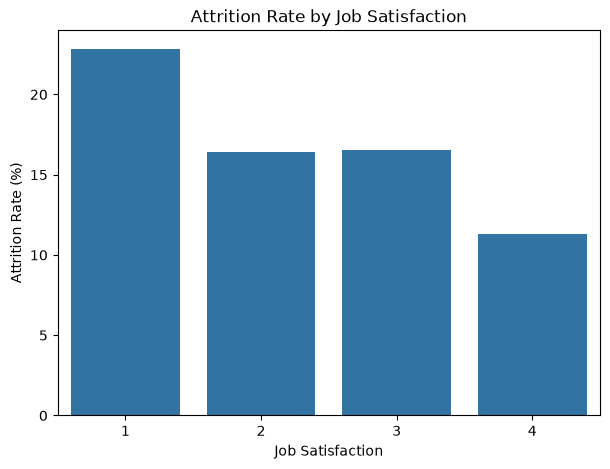

In [43]:
# ES: Visualizar la tasa de attrition según satisfacción laboral.
# EN: Visualize attrition rate by job satisfaction level.

plt.figure(figsize=(7, 5))

sns.barplot(
    data=job_satisfaction_attrition_yes,
    x="JobSatisfaction",
    y="Percentage"
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Interpretation

#### ES

La tasa de attrition disminuye a medida que aumenta la satisfacción laboral.

Los empleados con `JobSatisfaction = 1` presentan una tasa de attrition del **22,84 %**, mientras que los empleados con `JobSatisfaction = 4` presentan una tasa menor, del **11,33 %**.

Los niveles intermedios (`2` y `3`) muestran tasas similares, en torno al **16,5 %**.

Esto sugiere que una baja satisfacción laboral está asociada con una mayor probabilidad de salida de la empresa.

---

#### EN

The attrition rate decreases as job satisfaction increases.

Employees with `JobSatisfaction = 1` show an attrition rate of **22.84%**, while employees with `JobSatisfaction = 4` show a lower rate of **11.33%**.

Intermediate levels (`2` and `3`) show similar rates, around **16.5%**.

This suggests that low job satisfaction is associated with a higher probability of leaving the company.

### Business Insight

#### ES

La satisfacción laboral aparece como un factor relevante para explicar la rotación de empleados.

Desde una perspectiva de Recursos Humanos, mejorar la satisfacción laboral podría ser una palanca preventiva para reducir el abandono de talento.

Para nuestro proyecto, este resultado complementa el análisis de burnout: aunque satisfacción laboral y burnout no son lo mismo, ambos están relacionados con el bienestar del empleado y pueden ayudar a construir una visión más completa del riesgo asociado a determinados puestos o condiciones laborales.

---

#### EN

Job satisfaction appears to be a relevant factor for explaining employee attrition.

From an HR perspective, improving job satisfaction could be a preventive lever to reduce talent loss.

For our project, this finding complements the burnout analysis: although job satisfaction and burnout are not the same, both are related to employee wellbeing and can help build a more complete view of the risk associated with specific job roles or working conditions.

## 8.6 WorkLifeBalance vs Attrition

### ES

En esta sección analizamos la relación entre el equilibrio vida-trabajo (`WorkLifeBalance`) y la rotación de empleados (`Attrition`).

`WorkLifeBalance` es una variable ordinal que representa la percepción del empleado sobre su equilibrio entre vida personal y trabajo.

Este análisis es relevante porque un peor equilibrio vida-trabajo puede estar asociado con mayor desgaste, insatisfacción y probabilidad de salida de la empresa.

---

### EN

In this section we analyse the relationship between work-life balance (`WorkLifeBalance`) and employee attrition (`Attrition`).

`WorkLifeBalance` is an ordinal variable that represents the employee's perception of their balance between personal life and work.

This analysis is relevant because poorer work-life balance may be associated with higher strain, dissatisfaction and probability of leaving the company.

In [44]:
# ES: Calcular la tasa de attrition según WorkLifeBalance.
# EN: Calculate attrition rate by WorkLifeBalance level.

work_life_balance_attrition_rate = (
    attrition_df
    .groupby("WorkLifeBalance")["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

work_life_balance_attrition_rate["Percentage"] = (
    work_life_balance_attrition_rate["Percentage"] * 100
).round(2)

display(work_life_balance_attrition_rate)

,WorkLifeBalance,Attrition,Percentage
0,1,No,68.75
1,1,Yes,31.25
2,2,No,83.14
3,2,Yes,16.86
4,3,No,85.78
5,3,Yes,14.22
6,4,No,82.35
7,4,Yes,17.65


In [45]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

work_life_balance_attrition_yes = work_life_balance_attrition_rate[
    work_life_balance_attrition_rate["Attrition"] == "Yes"
]

display(work_life_balance_attrition_yes)

,WorkLifeBalance,Attrition,Percentage
1,1,Yes,31.25
3,2,Yes,16.86
5,3,Yes,14.22
7,4,Yes,17.65


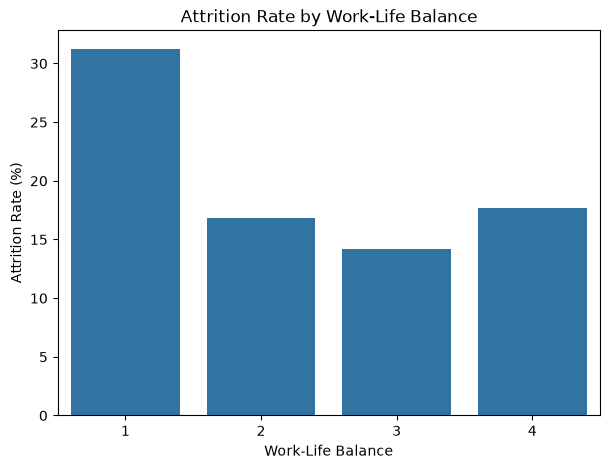

In [46]:
# ES: Visualizar la tasa de attrition según WorkLifeBalance.
# EN: Visualize attrition rate by WorkLifeBalance level.

plt.figure(figsize=(7, 5))

sns.barplot(
    data=work_life_balance_attrition_yes,
    x="WorkLifeBalance",
    y="Percentage"
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Interpretation

#### ES

La tasa de attrition es significativamente mayor entre los empleados con peor equilibrio entre vida personal y trabajo.

Los empleados con `WorkLifeBalance = 1` presentan una tasa de attrition del **31,25 %**, mientras que los niveles **2** y **3** muestran tasas inferiores (**16,86 %** y **14,22 %**, respectivamente).

Aunque el nivel **4** presenta una tasa ligeramente superior (**17,65 %**) respecto al nivel 3, la tendencia general indica que un mejor equilibrio vida-trabajo suele estar asociado con una menor rotación.

Este comportamiento también sugiere que el attrition depende de múltiples factores y no puede explicarse únicamente mediante una sola variable.

---

#### EN

The attrition rate is substantially higher among employees with poorer work-life balance.

Employees with `WorkLifeBalance = 1` show an attrition rate of **31.25%**, while levels **2** and **3** present lower rates (**16.86%** and **14.22%**, respectively).

Although level **4** shows a slightly higher rate (**17.65%**) than level 3, the overall trend suggests that better work-life balance is generally associated with lower employee turnover.

This behaviour also indicates that attrition is influenced by multiple factors and cannot be explained by a single variable alone.

### Business Insight

#### ES

El equilibrio entre la vida personal y el trabajo aparece como un factor asociado a la permanencia de los empleados en la organización.

Sin embargo, los resultados muestran que esta variable no explica por sí sola la rotación, lo que refuerza la necesidad de construir modelos predictivos que combinen múltiples factores.

Para nuestro proyecto, este hallazgo es especialmente relevante. La futura aplicación no debería estimar el riesgo de burnout utilizando una única variable, sino integrar información relacionada con la carga de trabajo, el descanso, la satisfacción laboral y otros indicadores del entorno laboral para ofrecer una evaluación más realista.

---

#### EN

Work-life balance appears to be a factor associated with employee retention.

However, the results show that this variable alone does not fully explain employee turnover, reinforcing the need to build predictive models that combine multiple factors.

For our project, this finding is particularly relevant. The future application should not estimate burnout risk using a single variable, but instead combine information related to workload, rest, job satisfaction and other workplace indicators to provide a more realistic assessment.

## 8.7 JobRole vs Attrition

### ES

En esta sección analizamos la relación entre el puesto de trabajo (`JobRole`) y la rotación de empleados (`Attrition`).

Este análisis es especialmente relevante para el proyecto porque el puesto de trabajo puede ser una de las variables principales de entrada en la futura aplicación.

Analizar qué roles presentan mayores tasas de rotación puede ayudar a contextualizar qué perfiles laborales podrían estar más expuestos a desgaste, insatisfacción o abandono.

---

### EN

In this section we analyse the relationship between job role (`JobRole`) and employee attrition (`Attrition`).

This analysis is especially relevant for the project because job role may become one of the main input variables in the final application.

Analysing which roles show higher attrition rates can help contextualise which job profiles may be more exposed to strain, dissatisfaction or turnover.

In [47]:
# ES: Calcular la tasa de attrition por puesto de trabajo.
# EN: Calculate attrition rate by job role.

job_role_attrition_rate = (
    attrition_df
    .groupby("JobRole")["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

job_role_attrition_rate["Percentage"] = (
    job_role_attrition_rate["Percentage"] * 100
).round(2)

display(job_role_attrition_rate)

,JobRole,Attrition,Percentage
0,Healthcare Representative,No,93.13
1,Healthcare Representative,Yes,6.87
2,Human Resources,No,76.92
3,Human Resources,Yes,23.08
4,Laboratory Technician,No,76.06
5,Laboratory Technician,Yes,23.94
6,Manager,No,95.10
7,Manager,Yes,4.90
8,Manufacturing Director,No,93.10
9,Manufacturing Director,Yes,6.90


In [48]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

job_role_attrition_yes = job_role_attrition_rate[
    job_role_attrition_rate["Attrition"] == "Yes"
].sort_values(by="Percentage", ascending=False)

display(job_role_attrition_yes)

,JobRole,Attrition,Percentage
17,Sales Representative,Yes,39.76
5,Laboratory Technician,Yes,23.94
3,Human Resources,Yes,23.08
15,Sales Executive,Yes,17.48
13,Research Scientist,Yes,16.10
9,Manufacturing Director,Yes,6.90
1,Healthcare Representative,Yes,6.87
7,Manager,Yes,4.90
11,Research Director,Yes,2.50


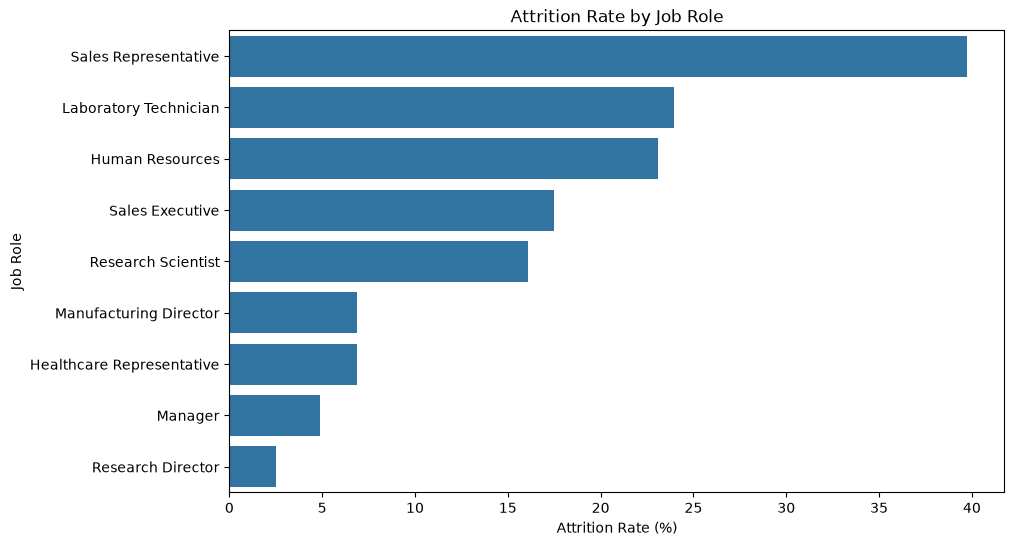

In [49]:
# ES: Visualizar la tasa de attrition por puesto de trabajo.
# EN: Visualize attrition rate by job role.

plt.figure(figsize=(10, 6))

sns.barplot(
    data=job_role_attrition_yes,
    x="Percentage",
    y="JobRole"
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

### Interpretation

#### ES

La tasa de attrition varía de forma importante según el puesto de trabajo.

Los puestos con mayor tasa de salida son:

- `Sales Representative`: **39,76 %**
- `Laboratory Technician`: **23,94 %**
- `Human Resources`: **23,08 %**
- `Sales Executive`: **17,48 %**
- `Research Scientist`: **16,10 %**

En cambio, los puestos con menor tasa de attrition son:

- `Research Director`: **2,50 %**
- `Manager`: **4,90 %**
- `Healthcare Representative`: **6,87 %**
- `Manufacturing Director`: **6,90 %**

Estos resultados indican que el puesto de trabajo está asociado con diferencias relevantes en la rotación de empleados.

---

#### EN

The attrition rate varies significantly depending on the job role.

The roles with the highest attrition rates are:

- `Sales Representative`: **39.76%**
- `Laboratory Technician`: **23.94%**
- `Human Resources`: **23.08%**
- `Sales Executive`: **17.48%**
- `Research Scientist`: **16.10%**

In contrast, the roles with the lowest attrition rates are:

- `Research Director`: **2.50%**
- `Manager`: **4.90%**
- `Healthcare Representative`: **6.87%**
- `Manufacturing Director`: **6.90%**

These results indicate that job role is associated with relevant differences in employee turnover.

### Business Insight

#### ES

El puesto de trabajo aparece como una variable especialmente relevante para contextualizar el riesgo laboral.

Desde una perspectiva de Recursos Humanos, algunos roles parecen estar más expuestos a rotación, posiblemente por factores como presión comercial, menor estabilidad, menor seniority, menor salario o condiciones laborales más exigentes.

Para nuestro proyecto, este análisis es clave porque permite utilizar el `JobRole` como punto de entrada de la aplicación. El usuario podría seleccionar un puesto y, a partir de ahí, la herramienta podría mostrar información contextual sobre riesgos asociados a ese tipo de perfil laboral.

No obstante, estos resultados no deben interpretarse como una relación causal directa. El puesto de trabajo debe analizarse junto con otras variables como horas extra, salario, satisfacción, antigüedad y equilibrio vida-trabajo.

---

#### EN

Job role appears to be a particularly relevant variable for contextualising work-related risk.

From an HR perspective, some roles seem to be more exposed to turnover, possibly due to factors such as commercial pressure, lower stability, lower seniority, lower salary or more demanding working conditions.

For our project, this analysis is key because `JobRole` can be used as an entry point in the final application. The user could select a job role and the tool could then display contextual information about risks associated with that type of work profile.

However, these results should not be interpreted as a direct causal relationship. Job role should be analysed together with other variables such as overtime, salary, satisfaction, tenure and work-life balance.

## 8.8 MonthlyIncome vs Attrition

### ES

En esta sección analizamos la relación entre los ingresos mensuales (`MonthlyIncome`) y la rotación de empleados (`Attrition`).

Este análisis es relevante porque el salario puede estar asociado con la permanencia en la empresa, la satisfacción laboral y las diferencias entre puestos.

---

### EN

In this section we analyse the relationship between monthly income (`MonthlyIncome`) and employee attrition (`Attrition`).

This analysis is relevant because salary may be associated with employee retention, job satisfaction and differences between job roles.

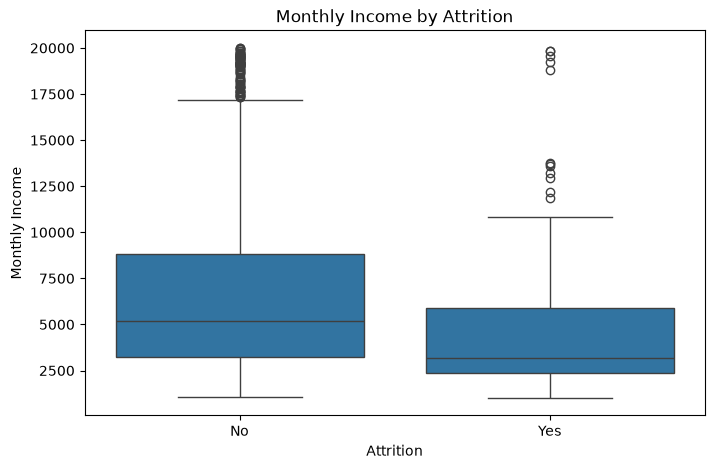

In [50]:
# ES: Comparar los ingresos mensuales según attrition.
# EN: Compare monthly income by attrition status.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=attrition_df,
    x="Attrition",
    y="MonthlyIncome",
    order=["No", "Yes"]
)

plt.title("Monthly Income by Attrition")
plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.show()

In [51]:
# ES: Calcular estadísticas de ingresos mensuales según attrition.
# EN: Calculate monthly income statistics by attrition status.

monthly_income_by_attrition = (
    attrition_df
    .groupby("Attrition")["MonthlyIncome"]
    .agg(["count", "mean", "median", "min", "max"])
    .loc[["No", "Yes"]]
    .round(2)
)

display(monthly_income_by_attrition)

,count,mean,median,min,max
Attrition,,,,,
No,1233,6832.74,5204.0,1051,19999
Yes,237,4787.09,3202.0,1009,19859


### Interpretation

#### ES

Los empleados que abandonaron la empresa presentan ingresos mensuales inferiores a los empleados que permanecieron.

El grupo con `Attrition = No` tiene un ingreso medio de **6.832,74**, mientras que el grupo con `Attrition = Yes` tiene un ingreso medio de **4.787,09**.

También se observa diferencia en la mediana: **5.204** para empleados que permanecen frente a **3.202** para empleados que abandonan.

Esto sugiere que menores ingresos están asociados con una mayor probabilidad de attrition.

---

#### EN

Employees who left the company show lower monthly income than those who remained.

The group with `Attrition = No` has an average monthly income of **6,832.74**, while the group with `Attrition = Yes` has an average income of **4,787.09**.

There is also a difference in the median: **5,204** for employees who stay versus **3,202** for employees who leave.

This suggests that lower income is associated with a higher probability of attrition.

### Business Insight

#### ES

El salario aparece como una variable relevante para contextualizar la rotación de empleados.

Desde una perspectiva de Recursos Humanos, los empleados con menores ingresos podrían estar más expuestos a buscar nuevas oportunidades o a abandonar la organización.

Para nuestro proyecto, este resultado ayuda a interpretar por qué algunos puestos pueden presentar mayor rotación: el riesgo no depende únicamente del rol, sino también de factores asociados como salario, seniority, carga laboral y satisfacción.

---

#### EN

Salary appears to be a relevant variable for contextualising employee attrition.

From an HR perspective, employees with lower income may be more exposed to seeking new opportunities or leaving the organisation.

For our project, this result helps interpret why some job roles may show higher turnover: risk does not depend only on the role itself, but also on associated factors such as salary, seniority, workload and satisfaction.

## 8.9 Department vs Attrition

### ES

En esta sección analizamos la relación entre el departamento (`Department`) y la rotación de empleados (`Attrition`).

Este análisis permite observar si la rotación se concentra más en unas áreas de la empresa que en otras.

---

### EN

In this section we analyse the relationship between department (`Department`) and employee attrition (`Attrition`).

This analysis helps identify whether employee turnover is more concentrated in some business areas than others.

In [52]:
# ES: Calcular la tasa de attrition por departamento.
# EN: Calculate attrition rate by department.

department_attrition_rate = (
    attrition_df
    .groupby("Department")["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

department_attrition_rate["Percentage"] = (
    department_attrition_rate["Percentage"] * 100
).round(2)

display(department_attrition_rate)

,Department,Attrition,Percentage
0,Human Resources,No,80.95
1,Human Resources,Yes,19.05
2,Research & Development,No,86.16
3,Research & Development,Yes,13.84
4,Sales,No,79.37
5,Sales,Yes,20.63


In [53]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

department_attrition_yes = department_attrition_rate[
    department_attrition_rate["Attrition"] == "Yes"
].sort_values(by="Percentage", ascending=False)

display(department_attrition_yes)

,Department,Attrition,Percentage
5,Sales,Yes,20.63
1,Human Resources,Yes,19.05
3,Research & Development,Yes,13.84


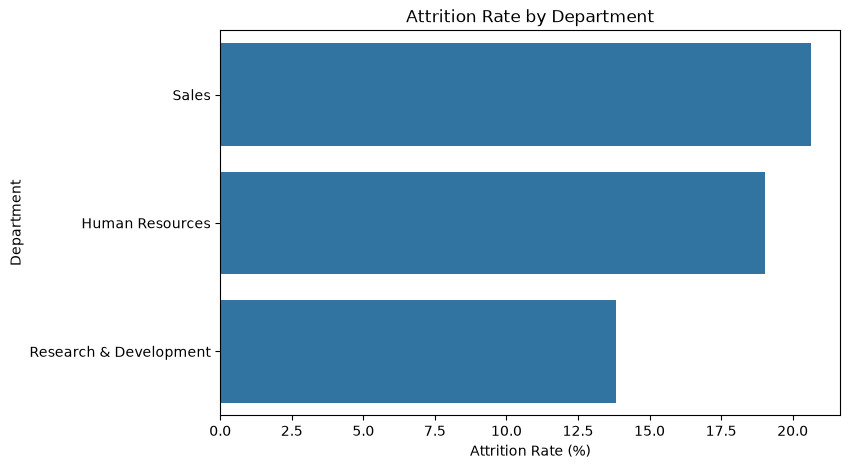

In [54]:
# ES: Visualizar la tasa de attrition por departamento.
# EN: Visualize attrition rate by department.

plt.figure(figsize=(8, 5))

sns.barplot(
    data=department_attrition_yes,
    x="Percentage",
    y="Department"
)

plt.title("Attrition Rate by Department")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Department")

plt.show()

### Interpretation

#### ES

La tasa de attrition presenta diferencias entre departamentos.

El departamento de **Sales** registra la mayor tasa de rotación (**20,63 %**), seguido de **Human Resources** (**19,05 %**). Por su parte, **Research & Development** presenta la menor tasa (**13,84 %**).

Estos resultados muestran que la rotación no afecta por igual a toda la organización, sino que determinados departamentos parecen concentrar una mayor proporción de empleados que abandonan la empresa.

---

#### EN

Attrition rates differ across departments.

The **Sales** department shows the highest turnover rate (**20.63%**), followed by **Human Resources** (**19.05%**). In contrast, **Research & Development** presents the lowest attrition rate (**13.84%**).

These results indicate that employee turnover is not evenly distributed across the organisation, with some departments concentrating a higher proportion of employees leaving the company.

### Business Insight

#### ES

El análisis por departamento complementa el estudio realizado por puesto de trabajo.

Mientras que el departamento permite identificar qué áreas de la organización presentan una mayor rotación, el análisis por `JobRole` permite localizar qué perfiles específicos concentran ese riesgo.

En nuestro proyecto, ambos niveles de información pueden utilizarse conjuntamente para enriquecer la aplicación. El puesto de trabajo será la principal variable de entrada, mientras que el departamento proporcionará contexto adicional para interpretar el nivel de riesgo asociado a cada perfil.

---

#### EN

Department analysis complements the previous job role analysis.

While departments identify the business areas with the highest employee turnover, the `JobRole` analysis pinpoints the specific profiles driving that turnover.

In our project, both levels of information can be combined to enrich the application. Job role will act as the main user input, while department will provide additional context for interpreting the associated risk.

## 8.10 JobRole and Department Attrition Analysis

### ES

En esta sección analizamos conjuntamente el departamento (`Department`) y el puesto de trabajo (`JobRole`) en relación con la rotación de empleados (`Attrition`).

Este análisis permite identificar no solo qué departamentos tienen mayor rotación, sino también qué puestos concretos dentro de cada departamento concentran mayores tasas de salida.

---

### EN

In this section we analyse department (`Department`) and job role (`JobRole`) together in relation to employee attrition (`Attrition`).

This analysis helps identify not only which departments have higher turnover, but also which specific roles within each department concentrate higher attrition rates.

In [55]:
# ES: Calcular la tasa de attrition por departamento y puesto.
# EN: Calculate attrition rate by department and job role.

department_job_role_attrition_rate = (
    attrition_df
    .groupby(["Department", "JobRole"])["Attrition"]
    .value_counts(normalize=True)
    .rename("Percentage")
    .reset_index()
)

department_job_role_attrition_rate["Percentage"] = (
    department_job_role_attrition_rate["Percentage"] * 100
).round(2)

display(department_job_role_attrition_rate)

,Department,JobRole,Attrition,Percentage
0,Human Resources,Human Resources,No,76.92
1,Human Resources,Human Resources,Yes,23.08
2,Human Resources,Manager,No,100.00
3,Research & Development,Healthcare Representative,No,93.13
4,Research & Development,Healthcare Representative,Yes,6.87
5,Research & Development,Laboratory Technician,No,76.06
6,Research & Development,Laboratory Technician,Yes,23.94
7,Research & Development,Manager,No,94.44
8,Research & Development,Manager,Yes,5.56
9,Research & Development,Manufacturing Director,No,93.10


In [56]:
# ES: Filtrar solo los empleados que dejaron la empresa.
# EN: Filter only employees who left the company.

department_job_role_attrition_yes = (
    department_job_role_attrition_rate[
        department_job_role_attrition_rate["Attrition"] == "Yes"
    ]
    .sort_values(by="Percentage", ascending=False)
)

display(department_job_role_attrition_yes)

,Department,JobRole,Attrition,Percentage
20,Sales,Sales Representative,Yes,39.76
6,Research & Development,Laboratory Technician,Yes,23.94
1,Human Resources,Human Resources,Yes,23.08
18,Sales,Sales Executive,Yes,17.48
14,Research & Development,Research Scientist,Yes,16.10
10,Research & Development,Manufacturing Director,Yes,6.90
4,Research & Development,Healthcare Representative,Yes,6.87
8,Research & Development,Manager,Yes,5.56
16,Sales,Manager,Yes,5.41
12,Research & Development,Research Director,Yes,2.50


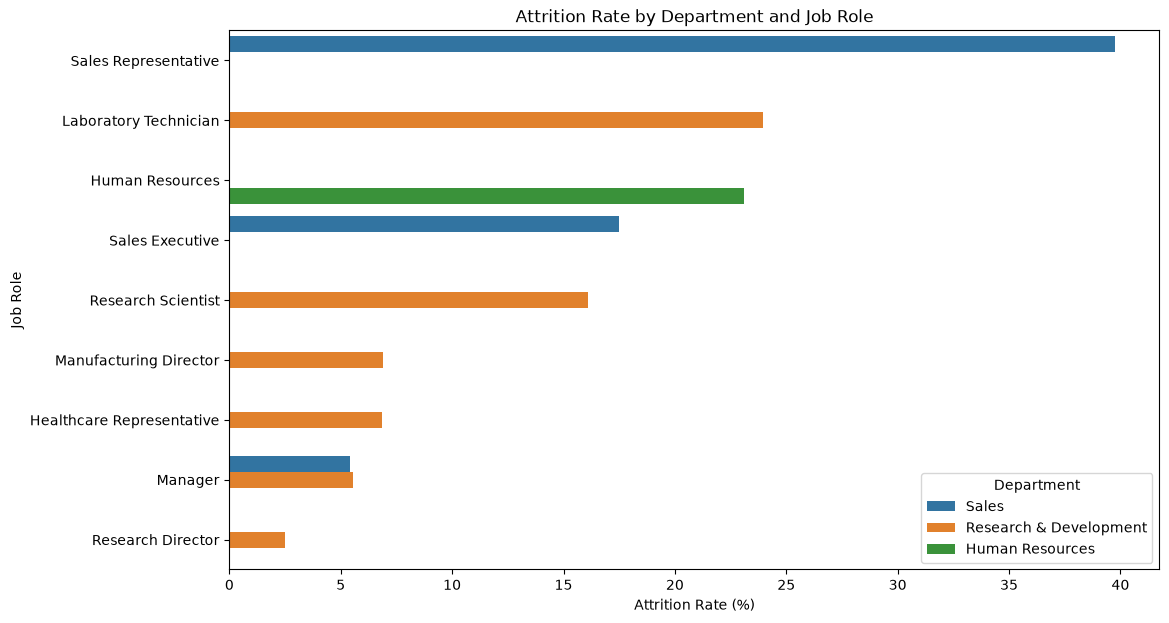

In [57]:
# ES: Visualizar la tasa de attrition por departamento y puesto.
# EN: Visualize attrition rate by department and job role.

plt.figure(figsize=(12, 7))

sns.barplot(
    data=department_job_role_attrition_yes,
    x="Percentage",
    y="JobRole",
    hue="Department"
)

plt.title("Attrition Rate by Department and Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")

plt.show()

### Interpretation

#### ES

El análisis combinado de `Department` y `JobRole` confirma que la rotación no se distribuye de forma uniforme dentro de la organización.

El puesto con mayor tasa de attrition es `Sales Representative`, dentro del departamento de **Sales**, con un **39,76 %**. También destacan `Laboratory Technician` en **Research & Development** (**23,94 %**) y `Human Resources` en el departamento de **Human Resources** (**23,08 %**).

Esto indica que no basta con analizar el departamento de forma general, ya que dentro de un mismo departamento pueden existir puestos con niveles de rotación muy diferentes.

---

#### EN

The combined analysis of `Department` and `JobRole` confirms that employee turnover is not evenly distributed across the organisation.

The role with the highest attrition rate is `Sales Representative`, within the **Sales** department, with **39.76%**. `Laboratory Technician` in **Research & Development** (**23.94%**) and `Human Resources` in the **Human Resources** department (**23.08%**) also stand out.

This indicates that analysing the department alone is not enough, as roles within the same department may show very different attrition levels.

### Business Insight

#### ES

Este análisis es especialmente útil para el diseño de la futura aplicación.

El usuario podría seleccionar primero un departamento y después un puesto concreto. A partir de esa selección, la herramienta podría mostrar información contextual sobre la rotación histórica asociada a ese perfil laboral.

Además, este análisis refuerza la idea de que el riesgo laboral debe evaluarse a nivel de puesto, no únicamente a nivel de empresa o departamento.

---

#### EN

This analysis is especially useful for designing the final application.

The user could first select a department and then a specific job role. Based on that selection, the tool could display contextual information about the historical attrition associated with that work profile.

This analysis also reinforces the idea that work-related risk should be assessed at the job-role level, not only at company or department level.

## 8.11 IBM Correlation Analysis

### ES

En esta sección analizamos la correlación entre las variables numéricas del dataset de IBM HR.

Antes de calcular la matriz de correlación, eliminaremos variables que no aportan valor analítico:

- `EmployeeCount`: variable constante.
- `StandardHours`: variable constante.
- `EmployeeNumber`: identificador del empleado.

Este análisis permitirá identificar relaciones lineales entre variables laborales, económicas y de antigüedad.

---

### EN

In this section we analyse the correlation between numerical variables in the IBM HR dataset.

Before calculating the correlation matrix, we remove variables that do not provide analytical value:

- `EmployeeCount`: constant variable.
- `StandardHours`: constant variable.
- `EmployeeNumber`: employee identifier.

This analysis helps identify linear relationships between job-related, financial and tenure variables.

In [58]:
# ES: Definir variables numéricas útiles para el análisis de correlación.
# EN: Define useful numerical variables for correlation analysis.

columns_to_exclude = [
    "EmployeeCount",
    "StandardHours",
    "EmployeeNumber"
]

attrition_correlation_columns = [
    column for column in attrition_numeric_columns
    if column not in columns_to_exclude
]

print("Variables used for correlation analysis:")
print(attrition_correlation_columns)

Variables used for correlation analysis:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [59]:
# ES: Calcular la matriz de correlación del dataset IBM HR.
# EN: Calculate the IBM HR correlation matrix.

attrition_correlation_matrix = attrition_df[attrition_correlation_columns].corr()

display(attrition_correlation_matrix.round(2))

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.00,0.01,-0.00,0.21,0.01,0.02,0.03,0.51,-0.00,0.50,0.03,0.30,0.00,0.00,0.05,0.04,0.68,-0.02,-0.02,0.31,0.21,0.22,0.20
DailyRate,0.01,1.00,-0.00,-0.02,0.02,0.02,0.05,0.00,0.03,0.01,-0.03,0.04,0.02,0.00,0.01,0.04,0.01,0.00,-0.04,-0.03,0.01,-0.03,-0.03
DistanceFromHome,-0.00,-0.00,1.00,0.02,-0.02,0.03,0.01,0.01,-0.00,-0.02,0.03,-0.03,0.04,0.03,0.01,0.04,0.00,-0.04,-0.03,0.01,0.02,0.01,0.01
Education,0.21,-0.02,0.02,1.00,-0.03,0.02,0.04,0.10,-0.01,0.09,-0.03,0.13,-0.01,-0.02,-0.01,0.02,0.15,-0.03,0.01,0.07,0.06,0.05,0.07
EnvironmentSatisfaction,0.01,0.02,-0.02,-0.03,1.00,-0.05,-0.01,0.00,-0.01,-0.01,0.04,0.01,-0.03,-0.03,0.01,0.00,-0.00,-0.02,0.03,0.00,0.02,0.02,-0.00
HourlyRate,0.02,0.02,0.03,0.02,-0.05,1.00,0.04,-0.03,-0.07,-0.02,-0.02,0.02,-0.01,-0.00,0.00,0.05,-0.00,-0.01,-0.00,-0.02,-0.02,-0.03,-0.02
JobInvolvement,0.03,0.05,0.01,0.04,-0.01,0.04,1.00,-0.01,-0.02,-0.02,-0.02,0.02,-0.02,-0.03,0.03,0.02,-0.01,-0.02,-0.01,-0.02,0.01,-0.02,0.03
JobLevel,0.51,0.00,0.01,0.10,0.00,-0.03,-0.01,1.00,-0.00,0.95,0.04,0.14,-0.03,-0.02,0.02,0.01,0.78,-0.02,0.04,0.53,0.39,0.35,0.38
JobSatisfaction,-0.00,0.03,-0.00,-0.01,-0.01,-0.07,-0.02,-0.00,1.00,-0.01,0.00,-0.06,0.02,0.00,-0.01,0.01,-0.02,-0.01,-0.02,-0.00,-0.00,-0.02,-0.03
MonthlyIncome,0.50,0.01,-0.02,0.09,-0.01,-0.02,-0.02,0.95,-0.01,1.00,0.03,0.15,-0.03,-0.02,0.03,0.01,0.77,-0.02,0.03,0.51,0.36,0.34,0.34


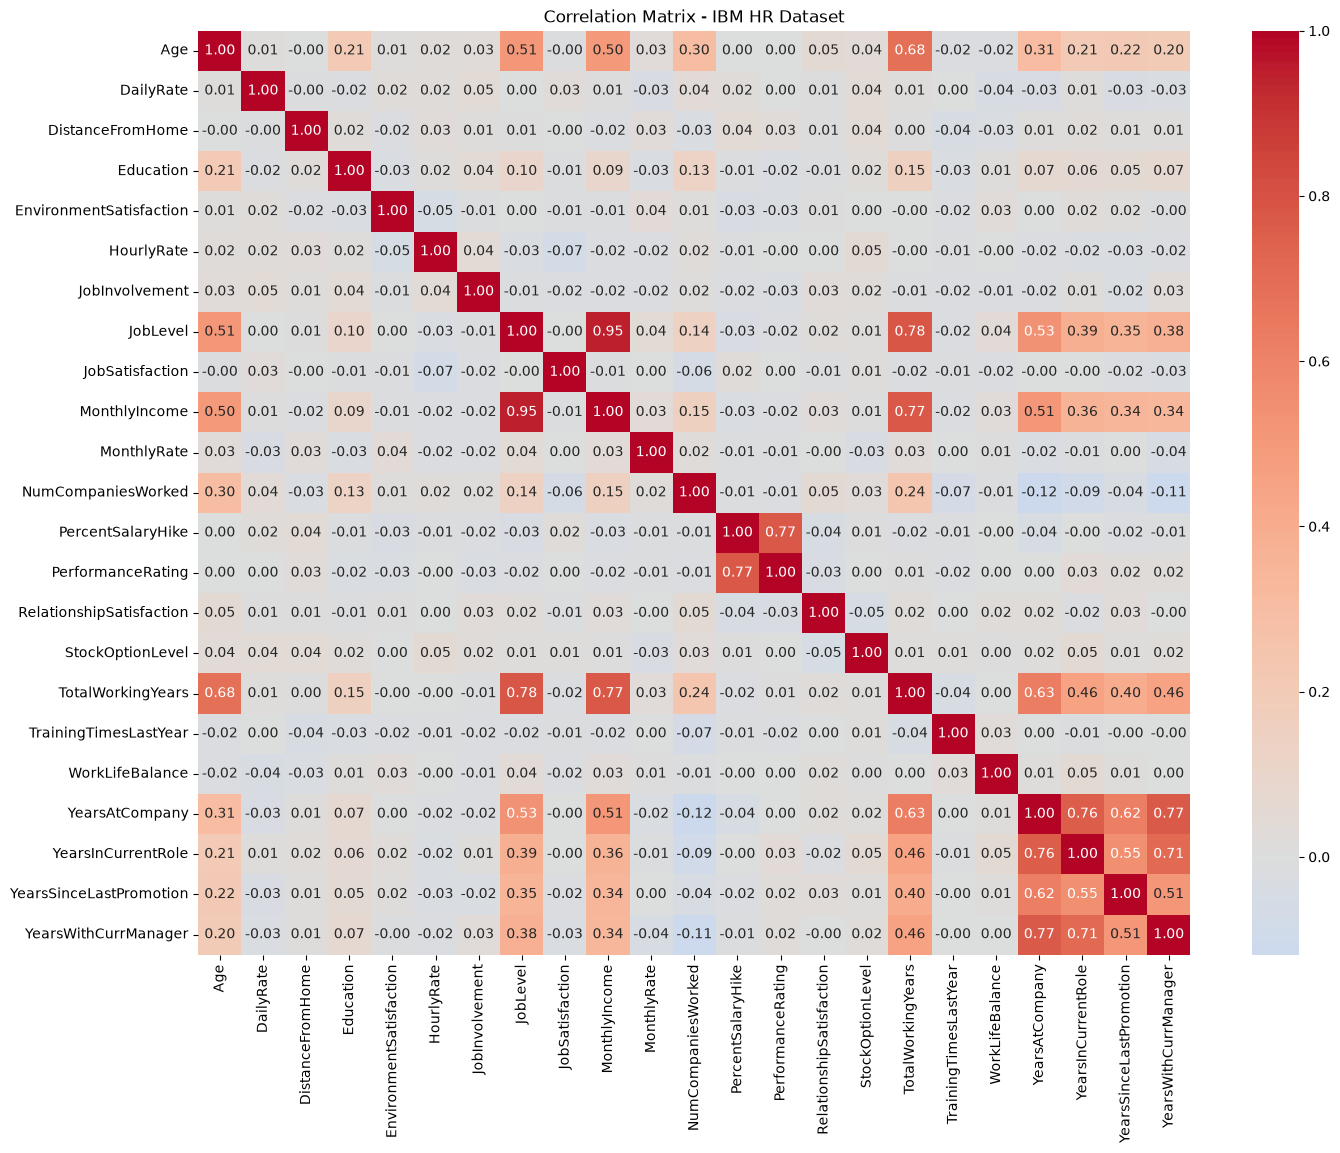

In [60]:
# ES: Visualizar la matriz de correlación con un heatmap.
# EN: Visualize the correlation matrix with a heatmap.

plt.figure(figsize=(16, 12))

sns.heatmap(
    attrition_correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - IBM HR Dataset")
plt.show()

In [61]:
# ES: Identificar correlaciones fuertes entre variables numéricas.
# EN: Identify strong correlations between numerical variables.

correlation_pairs = (
    attrition_correlation_matrix
    .abs()
    .unstack()
    .sort_values(ascending=False)
    .reset_index()
)

correlation_pairs.columns = ["Variable 1", "Variable 2", "Correlation"]

# ES: Eliminar correlaciones de una variable consigo misma.
# EN: Remove correlations of variables with themselves.

correlation_pairs = correlation_pairs[
    correlation_pairs["Variable 1"] != correlation_pairs["Variable 2"]
]

# ES: Eliminar duplicados simétricos.
# EN: Remove symmetric duplicates.

correlation_pairs["Pair"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variable 1"], row["Variable 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Pair").drop(columns="Pair")

# ES: Mostrar las correlaciones más fuertes.
# EN: Display the strongest correlations.

display(correlation_pairs.head(15))

,Variable 1,Variable 2,Correlation
23,JobLevel,MonthlyIncome,0.950300
25,TotalWorkingYears,JobLevel,0.782208
27,PercentSalaryHike,PerformanceRating,0.773550
29,MonthlyIncome,TotalWorkingYears,0.772893
31,YearsWithCurrManager,YearsAtCompany,0.769212
33,YearsAtCompany,YearsInCurrentRole,0.758754
35,YearsInCurrentRole,YearsWithCurrManager,0.714365
37,TotalWorkingYears,Age,0.680381
39,YearsAtCompany,TotalWorkingYears,0.628133
41,YearsAtCompany,YearsSinceLastPromotion,0.618409


### Interpretation

#### ES

El análisis de correlación muestra relaciones fuertes entre variables relacionadas con salario, experiencia, nivel del puesto y antigüedad.

Las correlaciones más altas son:

- `JobLevel` y `MonthlyIncome`: **0,95**
- `TotalWorkingYears` y `JobLevel`: **0,78**
- `MonthlyIncome` y `TotalWorkingYears`: **0,77**
- `YearsWithCurrManager` y `YearsAtCompany`: **0,77**
- `YearsAtCompany` y `YearsInCurrentRole`: **0,76**

Estos resultados son coherentes: empleados con mayor experiencia suelen tener niveles de puesto más altos, mayores ingresos y más años dentro de la empresa.

---

#### EN

The correlation analysis shows strong relationships between salary, experience, job level and tenure-related variables.

The strongest correlations are:

- `JobLevel` and `MonthlyIncome`: **0.95**
- `TotalWorkingYears` and `JobLevel`: **0.78**
- `MonthlyIncome` and `TotalWorkingYears`: **0.77**
- `YearsWithCurrManager` and `YearsAtCompany`: **0.77**
- `YearsAtCompany` and `YearsInCurrentRole`: **0.76**

These results are consistent: employees with more experience tend to have higher job levels, higher income and more years within the company.

### Business Insight

#### ES

Las correlaciones muestran que el dataset de IBM contiene varios bloques de variables relacionadas entre sí.

Por ejemplo, salario, experiencia y nivel del puesto están fuertemente conectados. Esto puede ser útil para entender perfiles laborales, pero también deberá tenerse en cuenta en el modelado para evitar redundancia entre variables.

Para nuestro proyecto, este análisis ayuda a contextualizar los puestos de trabajo: algunos roles pueden presentar mayor attrition no solo por el puesto en sí, sino por factores asociados como menor salario, menor seniority o menor antigüedad.

---

#### EN

The correlations show that the IBM dataset contains several groups of related variables.

For example, salary, experience and job level are strongly connected. This is useful for understanding job profiles, but it should also be considered during modelling to avoid redundancy between features.

For our project, this analysis helps contextualise job roles: some roles may present higher attrition not only because of the role itself, but also because of associated factors such as lower income, lower seniority or shorter tenure.

## 9. General EDA Conclusions

### ES

El análisis exploratorio ha permitido entender el papel de cada dataset dentro del proyecto.

El dataset de **burnout** será la base principal para estimar el riesgo de burnout a partir de variables relacionadas con hábitos de trabajo, descanso, aislamiento, fatiga y carga laboral.

El dataset de **IBM HR Attrition** no mide burnout directamente, pero aporta contexto de Recursos Humanos sobre rotación, puestos, departamentos, salario, satisfacción y equilibrio vida-trabajo.

---

### EN

The exploratory analysis helped clarify the role of each dataset within the project.

The **burnout** dataset will be the main source for estimating burnout risk based on work habits, rest, isolation, fatigue and workload-related variables.

The **IBM HR Attrition** dataset does not measure burnout directly, but it provides HR context about employee turnover, job roles, departments, salary, satisfaction and work-life balance.

## Key Findings

### ES

Los principales hallazgos del análisis son:

- El riesgo alto de burnout representa solo el **6,9 %** del dataset, por lo que existe desbalanceo de clases.
- `burnout_risk` parece estar derivado de `burnout_score`, por lo que `burnout_score` no debería utilizarse como predictor.
- Las variables más asociadas con `burnout_score` son `fatigue_score`, `isolation_index`, `sleep_hours`, `work_hours` y `screen_time_hours`.
- En IBM HR, `OverTime`, `JobSatisfaction`, `WorkLifeBalance`, `JobRole`, `Department` y `MonthlyIncome` muestran relaciones relevantes con `Attrition`.
- `Sales Representative`, `Laboratory Technician` y `Human Resources` presentan las mayores tasas de attrition.
- `EmployeeCount`, `StandardHours` y `EmployeeNumber` deberían excluirse durante el preprocesado.

---

### EN

The main findings from the analysis are:

- High burnout risk represents only **6.9%** of the dataset, indicating class imbalance.
- `burnout_risk` appears to be derived from `burnout_score`, so `burnout_score` should not be used as a predictor.
- The variables most associated with `burnout_score` are `fatigue_score`, `isolation_index`, `sleep_hours`, `work_hours` and `screen_time_hours`.
- In IBM HR, `OverTime`, `JobSatisfaction`, `WorkLifeBalance`, `JobRole`, `Department` and `MonthlyIncome` show relevant relationships with `Attrition`.
- `Sales Representative`, `Laboratory Technician` and `Human Resources` show the highest attrition rates.
- `EmployeeCount`, `StandardHours` and `EmployeeNumber` should be excluded during preprocessing.

## Implications for the Next Phase

### ES

El análisis exploratorio realizado proporciona una base sólida para la fase de preprocesado y modelado.

Los principales aspectos identificados que deberán considerarse durante las siguientes etapas son:

- El dataset de burnout presenta un desbalanceo en la variable objetivo (`burnout_risk`), ya que la categoría **High** representa únicamente el **6,9 %** de las observaciones.
- La variable `burnout_score` muestra una relación directa con `burnout_risk`, por lo que será necesario evaluar cuidadosamente su utilización para evitar introducir información derivada de la variable objetivo.
- Se han identificado variables sin capacidad informativa (`EmployeeCount` y `StandardHours`) y un identificador (`EmployeeNumber`) dentro del dataset de IBM HR.
- El análisis ha puesto de manifiesto variables con una fuerte asociación con el burnout y con el attrition que podrán ser evaluadas durante la selección de variables y el entrenamiento de modelos predictivos.

---

### EN

The exploratory analysis provides a solid foundation for the preprocessing and modelling stages.

The main aspects identified that should be considered during the next phases are:

- The burnout dataset presents class imbalance, with the **High** burnout risk category representing only **6.9%** of the observations.
- `burnout_score` shows a direct relationship with `burnout_risk`; therefore, its use should be carefully evaluated to avoid introducing information derived from the target variable.
- Non-informative variables (`EmployeeCount` and `StandardHours`) and an identifier (`EmployeeNumber`) were identified in the IBM HR dataset.
- The analysis highlighted several variables strongly associated with burnout and attrition that may be evaluated during feature selection and predictive model development.

## Final Business Conclusion

### ES

El análisis exploratorio muestra que el riesgo de burnout está asociado principalmente con factores relacionados con la carga de trabajo, la fatiga, el descanso y el aislamiento laboral.

De forma complementaria, el análisis del dataset de IBM HR pone de manifiesto que variables organizativas como el puesto de trabajo, el departamento, la satisfacción laboral, el salario y el equilibrio entre la vida personal y profesional presentan asociaciones relevantes con la rotación de empleados.

Aunque ambos datasets proceden de fuentes independientes y analizan fenómenos diferentes, los resultados obtenidos permiten construir una visión complementaria del bienestar laboral.

Esta información servirá como base para el desarrollo del modelo predictivo y para la construcción de una aplicación orientada a apoyar la identificación temprana de condiciones laborales asociadas a un mayor riesgo de burnout.

---

### EN

The exploratory analysis shows that burnout risk is mainly associated with workload, fatigue, rest and workplace isolation.

Complementarily, the IBM HR dataset highlights that organisational variables such as job role, department, job satisfaction, salary and work-life balance are associated with employee attrition.

Although both datasets come from independent sources and analyse different phenomena, together they provide a complementary view of workplace wellbeing.

These findings provide the basis for developing the predictive model and for building an application aimed at supporting the early identification of working conditions associated with increased burnout risk.

## Project Limitations

### ES

Este proyecto combina dos datasets independientes con objetivos diferentes.

El dataset de burnout permite analizar factores asociados al riesgo de burnout, mientras que el dataset IBM HR estudia la rotación de empleados.

Al no corresponder a la misma población ni contener los mismos individuos, los resultados obtenidos no permiten establecer relaciones causales entre burnout y attrition.

En consecuencia, ambos datasets deben interpretarse como fuentes complementarias de información para comprender distintos aspectos del bienestar laboral.

---

### EN

This project combines two independent datasets with different objectives.

The burnout dataset analyses factors associated with burnout risk, whereas the IBM HR dataset focuses on employee attrition.

Since both datasets represent different populations and do not contain the same individuals, the results cannot be used to establish causal relationships between burnout and attrition.

Therefore, both datasets should be interpreted as complementary sources of information for understanding different aspects of workplace wellbeing.